In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd


class mGRUCell(nn.Module):
    def __init__(self, hid, emb, device):
        super().__init__()

        self.hid = hid
        self.emb = emb

        self.W_r1 = nn.Parameter(torch.randn(hid, emb, device=device) * 0.1)
        self.W_r2 = nn.Parameter(torch.randn(hid, emb, device=device) * 0.1)
        self.U_r = nn.Parameter(torch.randn(hid, hid, device=device) * 0.1)
        self.B_wr = nn.Parameter(torch.ones(hid, hid, device=device) * 3.0)
        self.B_hr = nn.Parameter(torch.ones(hid, hid, device=device) * 3.0)

        self.W_z1 = nn.Parameter(torch.randn(hid, emb, device=device) * 0.1)
        self.W_z2 = nn.Parameter(torch.randn(hid, emb, device=device) * 0.1)
        self.U_z = nn.Parameter(torch.randn(hid, hid, device=device) * 0.1)
        self.B_wz = nn.Parameter(torch.ones(hid, hid, device=device) * 3.0)
        self.B_hz = nn.Parameter(torch.ones(hid, hid, device=device) * 3.0)

        self.W_1 = nn.Parameter(torch.randn(hid, emb, device=device) * 0.1)
        self.W_2 = nn.Parameter(torch.randn(hid, emb, device=device) * 0.1)
        self.U = nn.Parameter(torch.randn(hid, hid, device=device) * 0.1)
        self.B_wn = nn.Parameter(torch.ones(hid, hid, device=device) * 3.0)
        self.B_hn = nn.Parameter(torch.ones(hid, hid, device=device) * 3.0)

        self.query_linear = nn.Linear(emb, hid, bias=False, device=device)

        self.linear_pool = nn.Linear(hid, emb, device=device)

        self.init_hid = nn.Parameter(torch.randn(hid, hid, device=device) * 0.1)

    def forward(self, x, prev_hid_state):

        v_r1 = F.linear(x, self.W_r1) # (batch_size, hid)
        v_r2 = F.linear(x, self.W_r2) # (batch_size, hid)

        Wr_tilde = torch.einsum('bi,bj->bij', v_r1, v_r2) + self.B_wr
        w_H_r = torch.einsum('ij,bjk->bik', self.U_r, prev_hid_state) + self.B_hr 
        R = torch.sigmoid(Wr_tilde + w_H_r)
        

        v_z1 = F.linear(x, self.W_z1)
        v_z2 = F.linear(x, self.W_z2)
        Wz_tilde = torch.einsum('bi,bj->bij', v_z1, v_z2) + self.B_wz
        w_H_z = torch.einsum('ij,bjk->bik', self.U_z, prev_hid_state) + self.B_hz
        Z = torch.sigmoid(Wz_tilde + w_H_z)

        v_1 = F.linear(x, self.W_1)
        v_2 = F.linear(x, self.W_2)
        W_tilde = torch.einsum('bi,bj->bij', v_1, v_2) + self.B_wn
        w_H = torch.einsum('ij,bjk->bik', self.U, R * prev_hid_state) + self.B_hn
        H_tilde = F.tanh(W_tilde + w_H)

        new_hidden = Z * prev_hid_state + (1 - Z) * H_tilde

        return new_hidden

class mGRU(nn.Module):
    def __init__(self, hid, emb, device):
        super().__init__()

        self.mGRUCell = mGRUCell(hid, emb, device)

    def forward(self, x, y):
        # x is of shape (batch, seq, emb)

        batch_size = x.shape[0]
        state = self.mGRUCell.init_hid.unsqueeze(0).expand(batch_size, -1, -1)
        logits_matrix = []

        for i in range(x.shape[1]-1): #last entry is <STARTCOPY>
            current_token = x[:, i] #(batch, dim)
            state = self.mGRUCell.forward(current_token, state)
        
        # The decoding starts here

        token = x[:, x.shape[1]-1] #load the <STARTCOPY> entry
        state = self.mGRUCell.forward(token, state)
        q = self.mGRUCell.query_linear(token)
        vector_state = torch.einsum('bjk,bk->bj', state, q)
        logits = self.mGRUCell.linear_pool(vector_state) #(batch, emb) FIRST NUMBER PREDICTION
        logits_matrix.append(logits)

        for i in range(y.shape[1] - 1): #Predict the rest of n-1 numbers
            token = y[:, i]
            state = self.mGRUCell.forward(token, state)
            q = self.mGRUCell.query_linear(token)
            vector_state = torch.einsum('bjk,bk->bj', state, q)
            logits = self.mGRUCell.linear_pool(vector_state) #(batch, emb)
            logits_matrix.append(logits)

        final_logits = torch.stack(logits_matrix, dim=1)

        return final_logits

    def predict_inference(self, x, vocab, max_len=30):

        batch_size = x.shape[0]
        state = self.mGRUCell.init_hid.unsqueeze(0).expand(batch_size, -1, -1)

        logits_matrix = []

        for i in range(x.shape[1]-1): #last entry is <STARTCOPY>
            current_token = x[:, i] #(batch, dim)
            state = self.mGRUCell.forward(current_token, state)
        
        # The decoding starts here

        token = x[:, x.shape[1]-1] #load the <STARTCOPY> entry
        state = self.mGRUCell.forward(token, state)
        q = self.mGRUCell.query_linear(token)
        vector_state = torch.einsum('bjk,bk->bj', state, q)
        logits = self.mGRUCell.linear_pool(vector_state) #(batch, emb)
        logits_matrix.append(logits)
        token = F.one_hot(torch.argmax(logits, dim=1), num_classes=len(vocab)).float() 
        step=0

        while step < max_len:
            state = self.mGRUCell.forward(token, state)
            q = self.mGRUCell.query_linear(token)
            vector_state = torch.einsum('bjk,bk->bj', state, q)
            logits = self.mGRUCell.linear_pool(vector_state) #(batch, emb)
            logits_matrix.append(logits)
            token = F.one_hot(torch.argmax(logits, dim=1), num_classes=len(vocab)).float()
            step= step +1

        final_logits = torch.stack(logits_matrix, dim=1)

        return final_logits

In [2]:
class CopyGRU(nn.Module): # To bench mGRU against
    def __init__(self, hid, emb, device="cuda"):
        super().__init__()

        self.init_hid = nn.Parameter(torch.randn(hid, device=device) * 0.1)
        self.GRUCell = nn.GRUCell(emb, hid, device=device)
        self.linear_proj = nn.Linear(hid, emb, device=device)

    def forward(self, x, y):

        batch_size = x.shape[0]
        state = self.init_hid.unsqueeze(0).expand(batch_size, -1)
        logits_matrix = []

        for i in range(x.shape[1]-1): #last entry is <STARTCOPY>
            current_token = x[:, i] #(batch, dim)
            state = self.GRUCell(current_token, state)
        
        # The decoding starts here

        token = x[:, x.shape[1]-1] #load the <STARTCOPY> entry
        state = self.GRUCell(token, state)
        logits = self.linear_proj(state) #(batch, emb)
        logits_matrix.append(logits)

        for i in range(y.shape[1] - 1):
            token = y[:, i]
            state = self.GRUCell(token, state)
            logits = self.linear_proj(state) #(batch, emb)
            logits_matrix.append(logits)

        final_logits = torch.stack(logits_matrix, dim=1)

        return final_logits

    
    def predict_inference(self, x, vocab, max_len=30):

        batch_size = x.shape[0]
        state = self.init_hid.unsqueeze(0).expand(batch_size, -1)

        logits_matrix = []

        for i in range(x.shape[1]-1): #last entry is <STARTCOPY>
            current_token = x[:, i] #(batch, dim)
            state = self.GRUCell(current_token, state)
        
        # The decoding starts here

        token = x[:, x.shape[1]-1] #load the <STARTCOPY> entry
        state = self.GRUCell(token, state)
        logits = self.linear_proj(state) #(batch, emb)
        logits_matrix.append(logits)
        token = F.one_hot(torch.argmax(logits, dim=1), num_classes=len(vocab)).float()
        step=0

        while step < max_len:
            state = self.GRUCell(token, state)
            logits = self.linear_proj(state) #(batch, emb)
            logits_matrix.append(logits)
            token = F.one_hot(torch.argmax(logits, dim=1), num_classes=len(vocab)).float()
            step = step + 1

        final_logits = torch.stack(logits_matrix, dim=1)

        return final_logits

### Experiment one - pure memory retension

In [3]:
# Build vocab

vocab = dict()

for i in range(10):
    vocab[i] = i

vocab["<ENDSEQ>"] = len(vocab)
vocab["<NOISE>"] = len(vocab)
vocab["<STARTCOPY>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

def get_batch_ex1(batch_size, copy_size=10, buffer_size=50, device='cuda'):
    copy_tensor = torch.randint(0, 10, (batch_size, copy_size), device=device)
    zero_tensor = torch.full((batch_size, buffer_size), vocab["<NOISE>"], device=device)
    marker_tensor = torch.full((batch_size, 1), vocab["<STARTCOPY>"], device=device)

    content_tensor = torch.cat((copy_tensor, zero_tensor), dim=1)
    ready_tensor = torch.cat((content_tensor, marker_tensor), dim=1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor


In [4]:
import matplotlib.pyplot as plt


def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Memory Retention Loss Curves (Buffer Length = 100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [5]:
def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

In [6]:
from tqdm.notebook import trange, tqdm
import random
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []

CopyGRU_model = CopyGRU(hid, emb)
opt = torch.optim.Adam(CopyGRU_model.parameters(), lr=lr)

def run_training_ex1(model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt, test_break, model_name):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(100, buffer_size)

        batch, targets = get_batch_ex1(batch_size, copy_size, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex1")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / 50
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex1(batch_size, copy_size, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


In [7]:
#import torch
#torch.cuda.empty_cache()

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

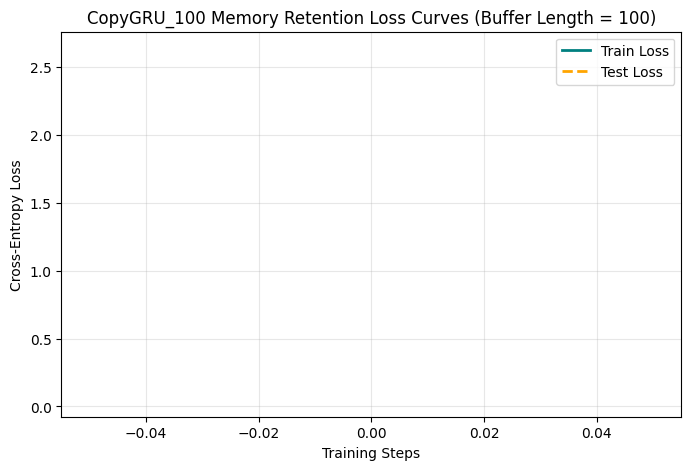

STEP: 0 | TRAIN LOSS: 0.0529 | TEST LOSS: 2.6332


KeyboardInterrupt: 

In [8]:
run_training_ex1(CopyGRU_model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt=opt, test_break=50, model_name="CopyGRU_100")

In [ ]:
hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []


mGRU_model = mGRU(hid, emb, device="cuda")
opt_m = torch.optim.Adam(mGRU_model.parameters(), lr=lr)

run_training_ex1(mGRU_model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt_m, test_break=50, model_name="mGRU_100")
save_model(mGRU_model, opt, 1, "mGRU_500", note="ex1")

In [ ]:
def evaluate_ex1(model, copy_size, buffer_size, total_batches, batch_size):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0

    for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

        batch, targets = get_batch_ex1(batch_size, copy_size, buffer_size) #targets = (batch, seq)
        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        logits = model.forward(batch, model_targets) # (batch, seq, emb)
        tokens = torch.argmax(logits, dim=2) # (batch, seq)

        difference = targets - tokens #we'll get some number where the numbers are not the same

        difference = (difference !=0).float()

        num_elements = copy_size * batch_size

        num_different = torch.sum(difference)

        avg_difference = num_different / num_elements

        avg_difference_sum = avg_difference_sum + avg_difference.item()

    return avg_difference_sum / (total_batches+1)


def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [10]:
hid_c=256
hid_m=16
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

CopyGRU_model = CopyGRU(hid_c, emb)
opt = torch.optim.Adam(CopyGRU_model.parameters(), lr=lr)

mGRU_model = mGRU(hid_m, emb, "cuda")
opt_m = torch.optim.Adam(mGRU_model.parameters(), lr=lr)

load_model("CopyGRU_100_ex1_epoch_7000.pt", "cuda", CopyGRU_model, opt)
load_model("mGRU_100_ex1_epoch_7000.pt", "cuda", mGRU_model, opt_m)

ex1_cgru_50 =   evaluate_ex1(CopyGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_100 =  evaluate_ex1(CopyGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_250 =  evaluate_ex1(CopyGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_500 =  evaluate_ex1(CopyGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_750 =  evaluate_ex1(CopyGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_1000 = evaluate_ex1(CopyGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("CopyGRU synthetic copy difference at buffer_size=50: ", ex1_cgru_50)
print("CopyGRU synthetic copy difference at buffer_size=100: ", ex1_cgru_100)
print("CopyGRU synthetic copy difference at buffer_size=250: ", ex1_cgru_250)
print("CopyGRU synthetic copy difference at buffer_size=500: ", ex1_cgru_500)
print("CopyGRU synthetic copy difference at buffer_size=750: ", ex1_cgru_750)
print("CopyGRU synthetic copy difference at buffer_size=1000: ", ex1_cgru_1000)

ex1_mgru_50 =   evaluate_ex1(mGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_mgru_100 =  evaluate_ex1(mGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_mgru_250 =  evaluate_ex1(mGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_mgru_500 =  evaluate_ex1(mGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_mgru_750 =  evaluate_ex1(mGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_mgru_1000 = evaluate_ex1(mGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("mGRU synthetic copy difference at buffer_size=50: ",   ex1_mgru_50)
print("mGRU synthetic copy difference at buffer_size=100: ",  ex1_mgru_100)
print("mGRU synthetic copy difference at buffer_size=250: ",  ex1_mgru_250)
print("mGRU synthetic copy difference at buffer_size=500: ",  ex1_mgru_500)
print("mGRU synthetic copy difference at buffer_size=750: ",  ex1_mgru_750)
print("mGRU synthetic copy difference at buffer_size=1000: ", ex1_mgru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mGRU synthetic copy difference at buffer_size=50:  0.5925742724154255
mGRU synthetic copy difference at buffer_size=100:  0.15931312157080904
mGRU synthetic copy difference at buffer_size=250:  0.5758663486726213
mGRU synthetic copy difference at buffer_size=500:  0.7635210522330633
mGRU synthetic copy difference at buffer_size=750:  0.8279393663500795
mGRU synthetic copy difference at buffer_size=1000:  0.8604888744873576


  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

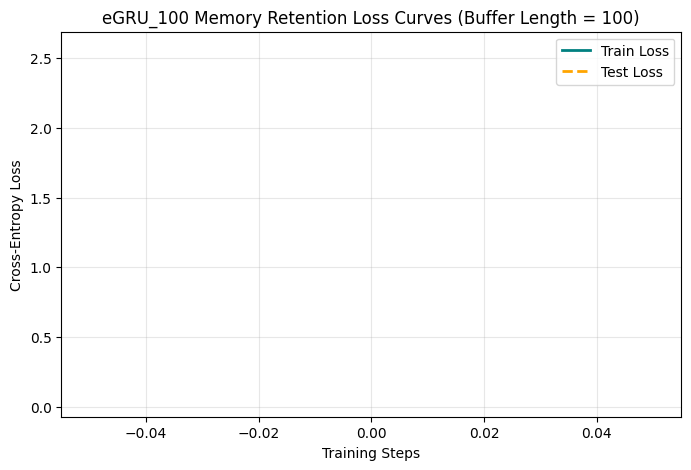

STEP: 0 | TRAIN LOSS: 0.0527 | TEST LOSS: 2.5652


  0%|          | 0/10 [00:00<?, ?it/s]

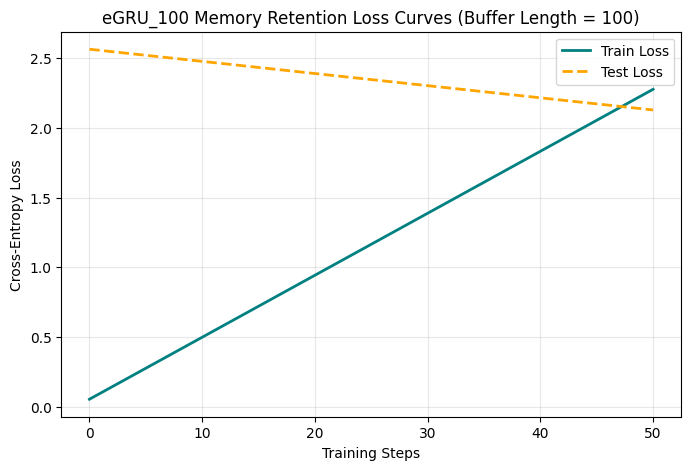

STEP: 50 | TRAIN LOSS: 2.2776 | TEST LOSS: 2.1292


  0%|          | 0/10 [00:00<?, ?it/s]

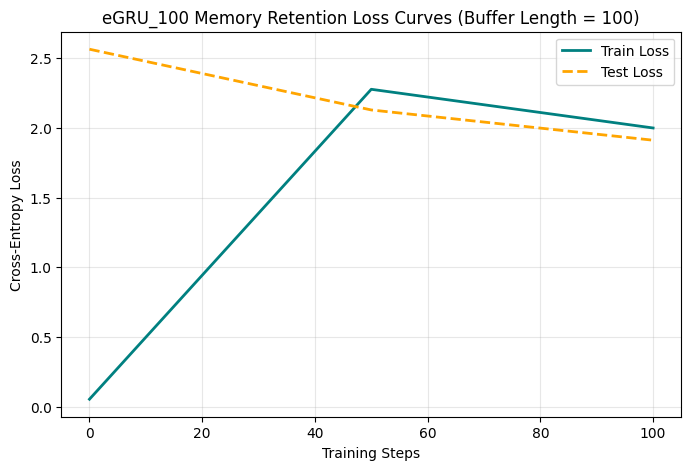

STEP: 100 | TRAIN LOSS: 1.9998 | TEST LOSS: 1.9119


  0%|          | 0/10 [00:00<?, ?it/s]

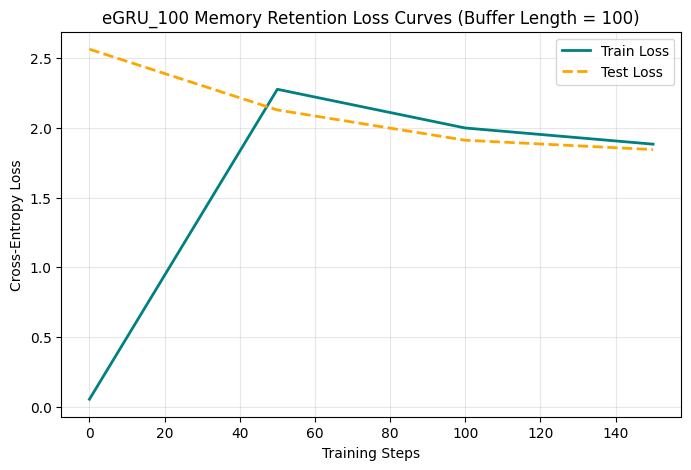

STEP: 150 | TRAIN LOSS: 1.8836 | TEST LOSS: 1.8447


  0%|          | 0/10 [00:00<?, ?it/s]

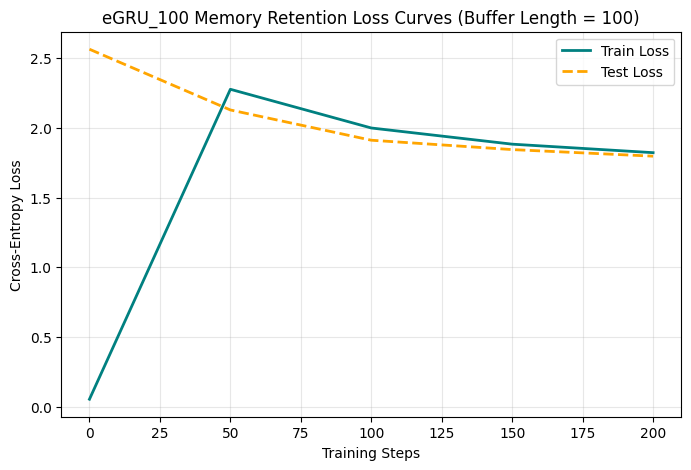

STEP: 200 | TRAIN LOSS: 1.8226 | TEST LOSS: 1.7974


  0%|          | 0/10 [00:00<?, ?it/s]

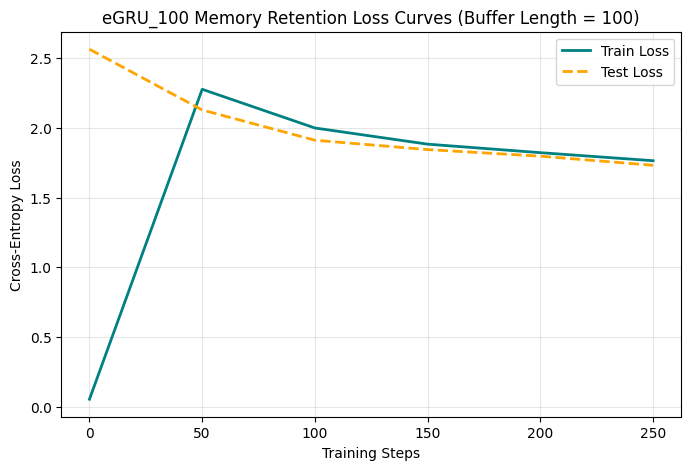

STEP: 250 | TRAIN LOSS: 1.7649 | TEST LOSS: 1.7319


  0%|          | 0/10 [00:00<?, ?it/s]

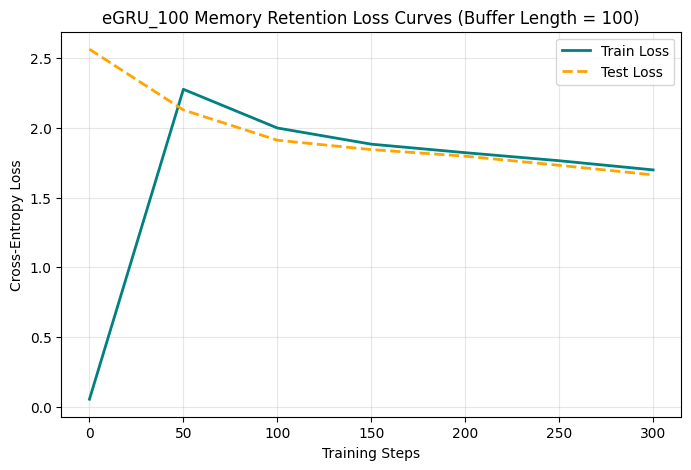

STEP: 300 | TRAIN LOSS: 1.6989 | TEST LOSS: 1.6631


  0%|          | 0/10 [00:00<?, ?it/s]

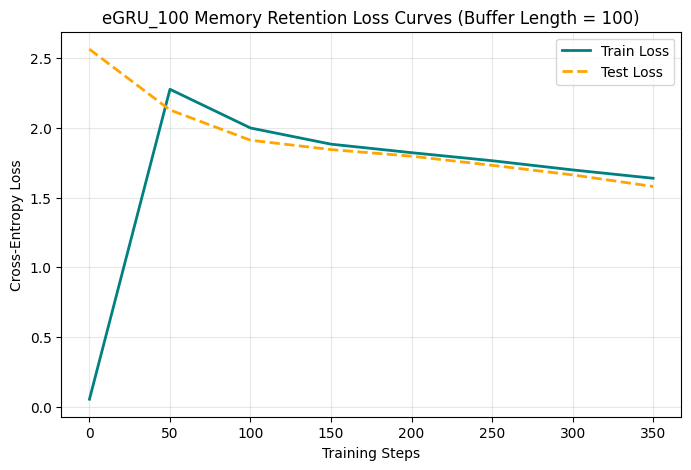

STEP: 350 | TRAIN LOSS: 1.6388 | TEST LOSS: 1.5800


  0%|          | 0/10 [00:00<?, ?it/s]

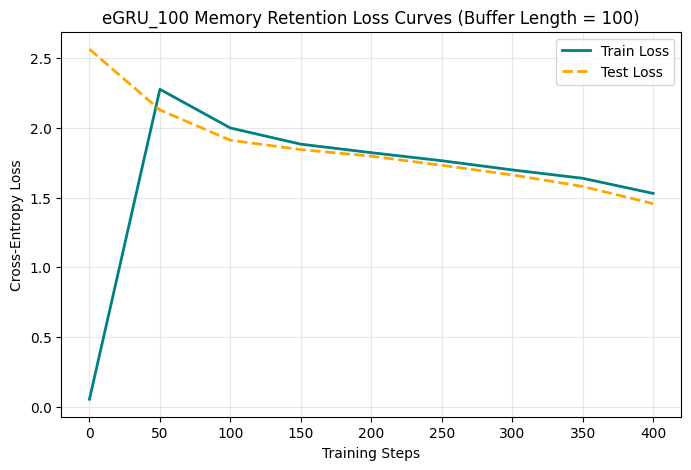

STEP: 400 | TRAIN LOSS: 1.5302 | TEST LOSS: 1.4569


  0%|          | 0/10 [00:00<?, ?it/s]

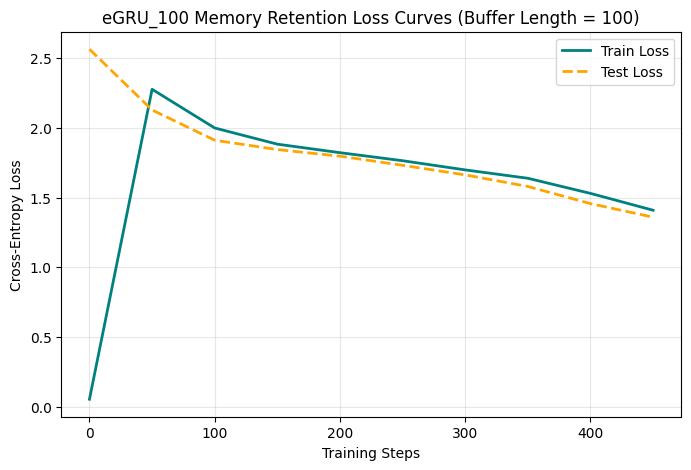

STEP: 450 | TRAIN LOSS: 1.4093 | TEST LOSS: 1.3593


  0%|          | 0/10 [00:00<?, ?it/s]

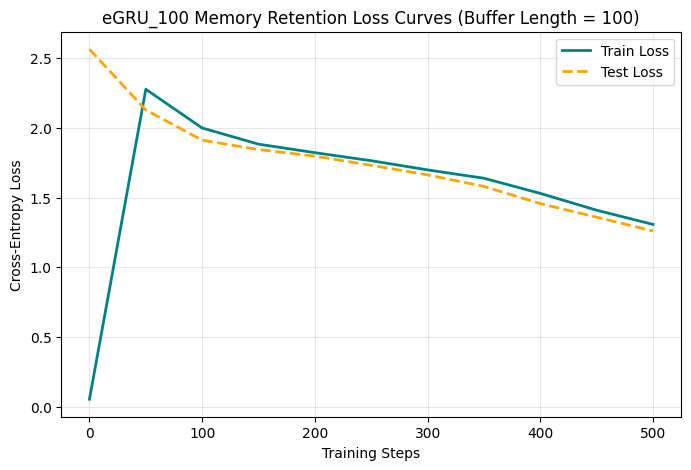

STEP: 500 | TRAIN LOSS: 1.3075 | TEST LOSS: 1.2601


  0%|          | 0/10 [00:00<?, ?it/s]

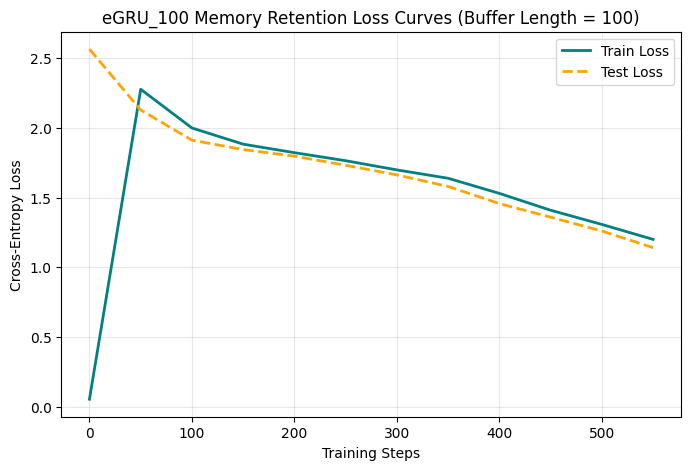

STEP: 550 | TRAIN LOSS: 1.2000 | TEST LOSS: 1.1407


  0%|          | 0/10 [00:00<?, ?it/s]

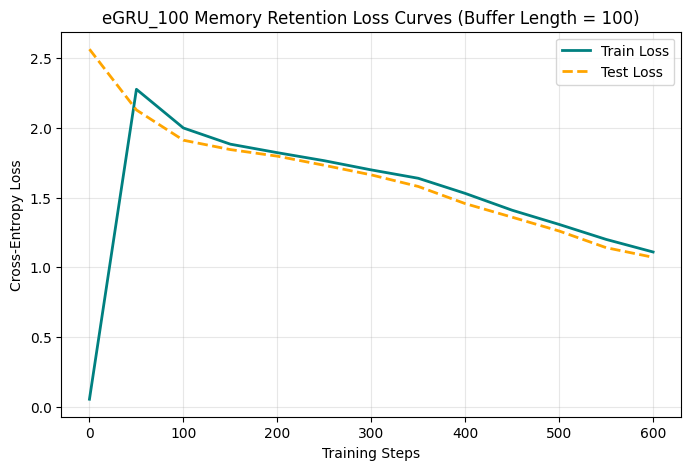

STEP: 600 | TRAIN LOSS: 1.1096 | TEST LOSS: 1.0715


  0%|          | 0/10 [00:00<?, ?it/s]

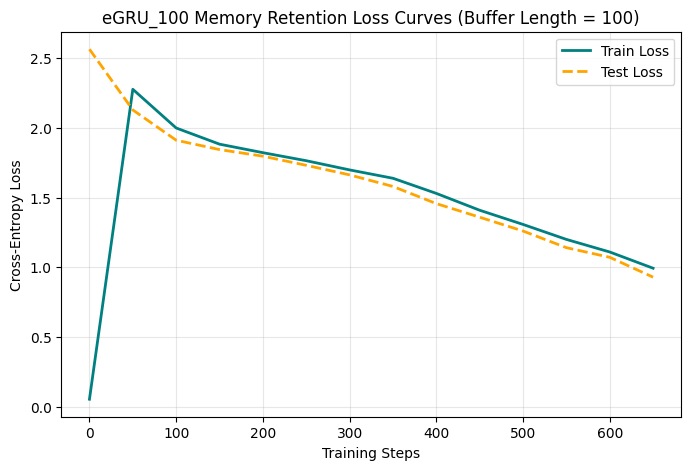

STEP: 650 | TRAIN LOSS: 0.9930 | TEST LOSS: 0.9289


  0%|          | 0/10 [00:00<?, ?it/s]

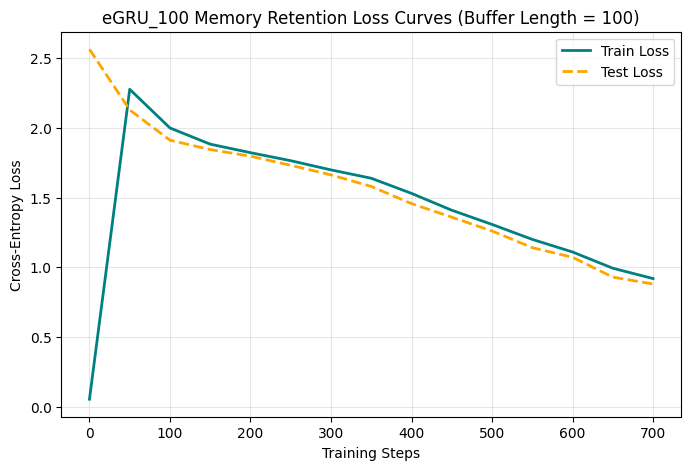

STEP: 700 | TRAIN LOSS: 0.9188 | TEST LOSS: 0.8801


  0%|          | 0/10 [00:00<?, ?it/s]

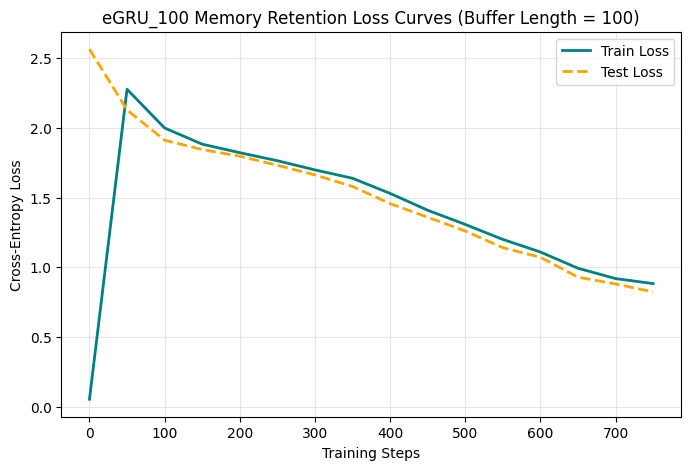

STEP: 750 | TRAIN LOSS: 0.8828 | TEST LOSS: 0.8230


  0%|          | 0/10 [00:00<?, ?it/s]

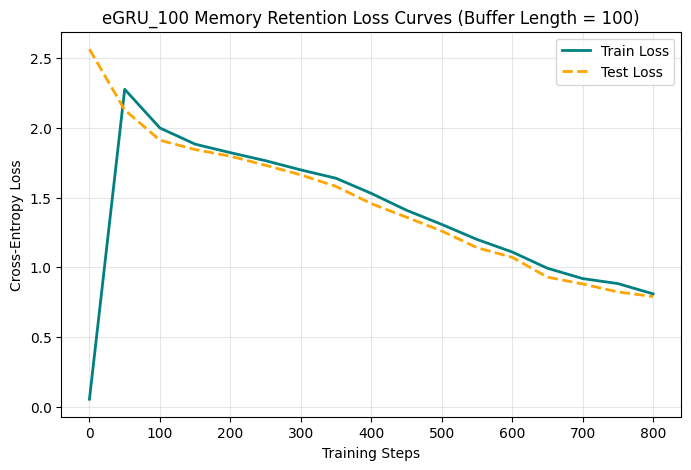

STEP: 800 | TRAIN LOSS: 0.8090 | TEST LOSS: 0.7896


  0%|          | 0/10 [00:00<?, ?it/s]

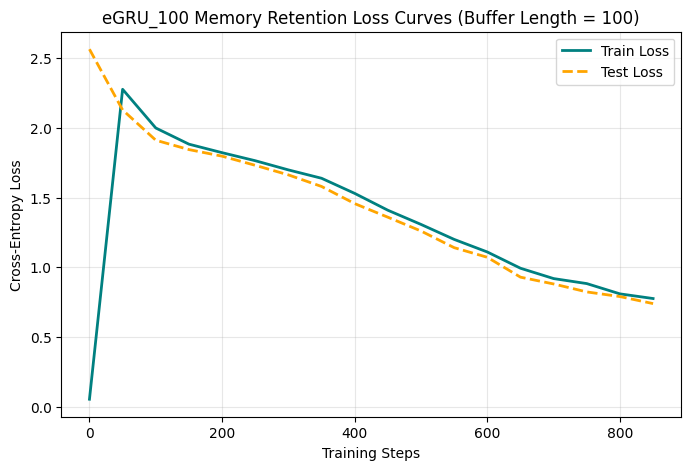

STEP: 850 | TRAIN LOSS: 0.7755 | TEST LOSS: 0.7392


  0%|          | 0/10 [00:00<?, ?it/s]

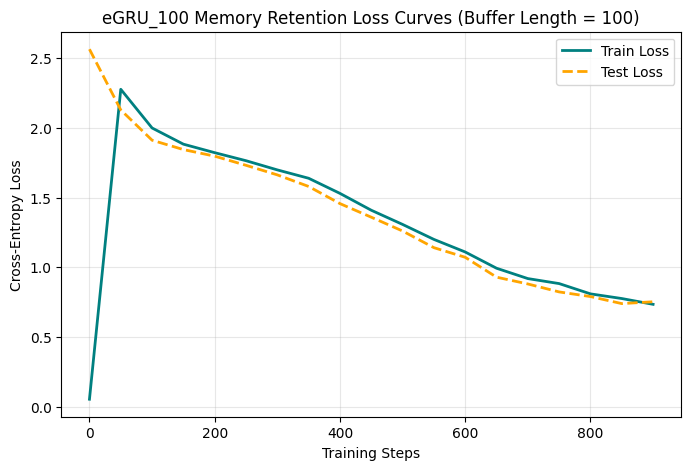

STEP: 900 | TRAIN LOSS: 0.7339 | TEST LOSS: 0.7523


  0%|          | 0/10 [00:00<?, ?it/s]

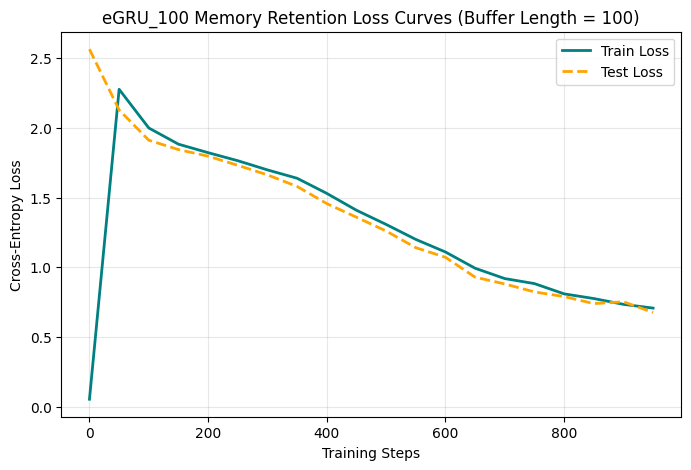

STEP: 950 | TRAIN LOSS: 0.7069 | TEST LOSS: 0.6753


  0%|          | 0/10 [00:00<?, ?it/s]

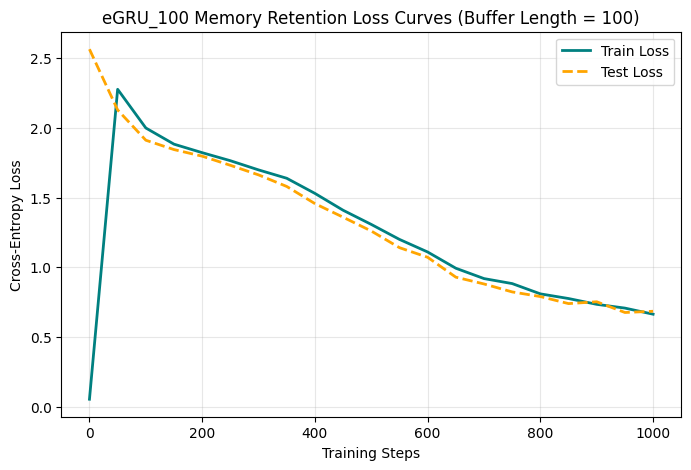

STEP: 1000 | TRAIN LOSS: 0.6631 | TEST LOSS: 0.6842


  0%|          | 0/10 [00:00<?, ?it/s]

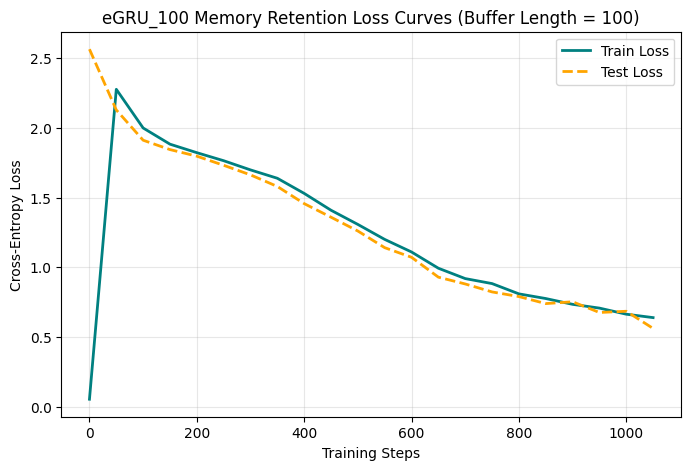

STEP: 1050 | TRAIN LOSS: 0.6386 | TEST LOSS: 0.5609


  0%|          | 0/10 [00:00<?, ?it/s]

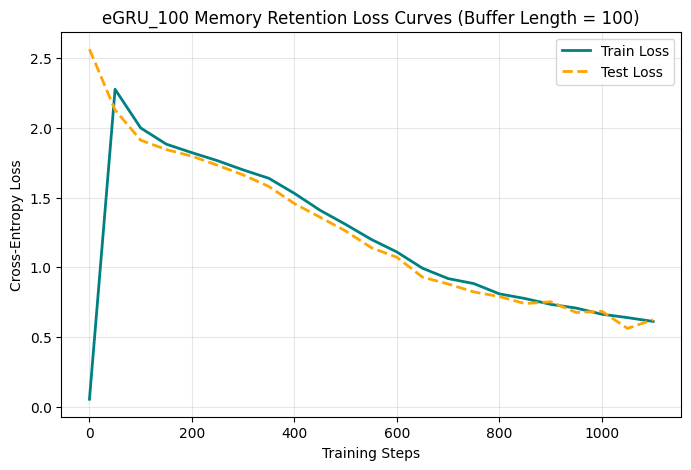

STEP: 1100 | TRAIN LOSS: 0.6113 | TEST LOSS: 0.6234


  0%|          | 0/10 [00:00<?, ?it/s]

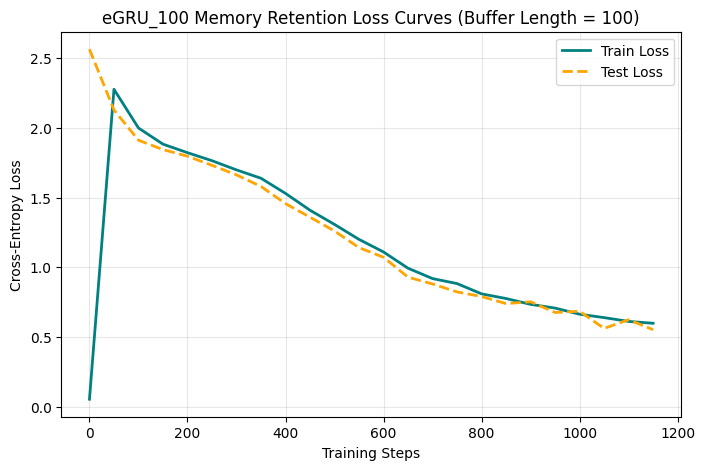

STEP: 1150 | TRAIN LOSS: 0.5979 | TEST LOSS: 0.5518


  0%|          | 0/10 [00:00<?, ?it/s]

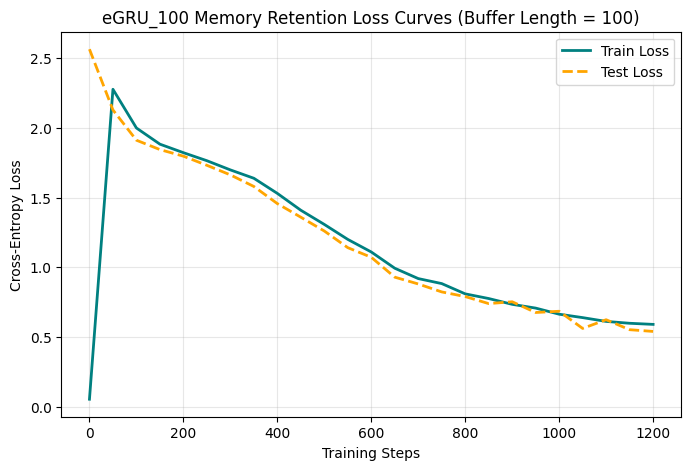

STEP: 1200 | TRAIN LOSS: 0.5900 | TEST LOSS: 0.5394


  0%|          | 0/10 [00:00<?, ?it/s]

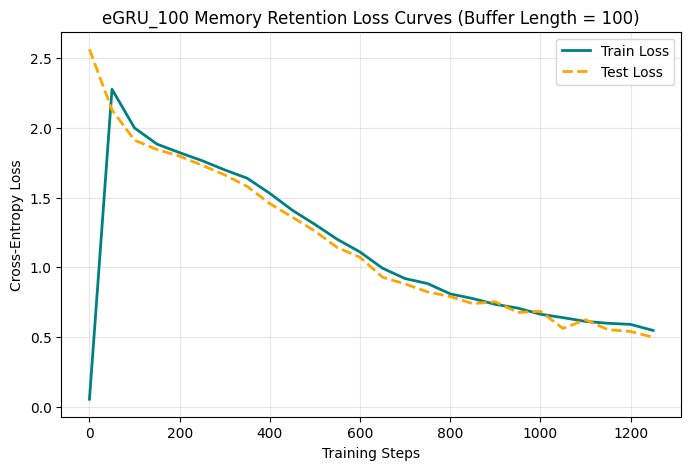

STEP: 1250 | TRAIN LOSS: 0.5465 | TEST LOSS: 0.4972


  0%|          | 0/10 [00:00<?, ?it/s]

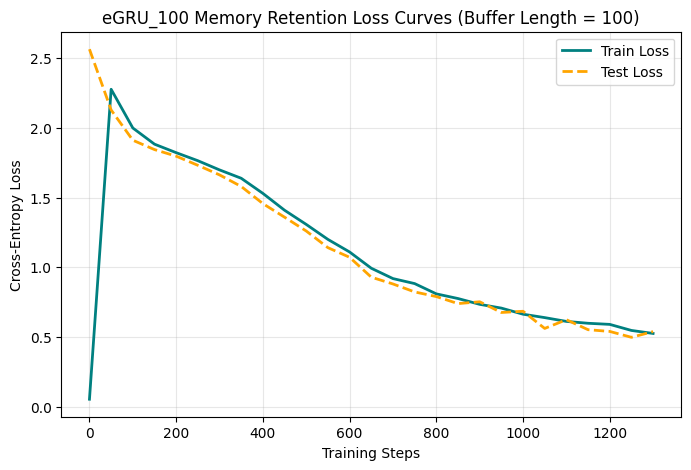

STEP: 1300 | TRAIN LOSS: 0.5249 | TEST LOSS: 0.5382


  0%|          | 0/10 [00:00<?, ?it/s]

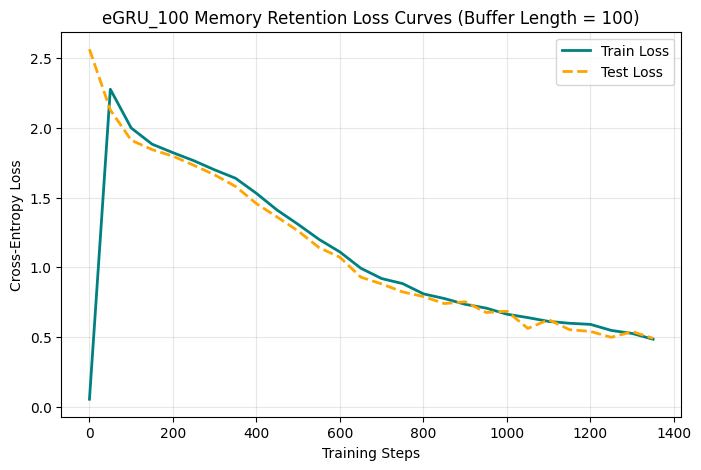

STEP: 1350 | TRAIN LOSS: 0.4835 | TEST LOSS: 0.4897


  0%|          | 0/10 [00:00<?, ?it/s]

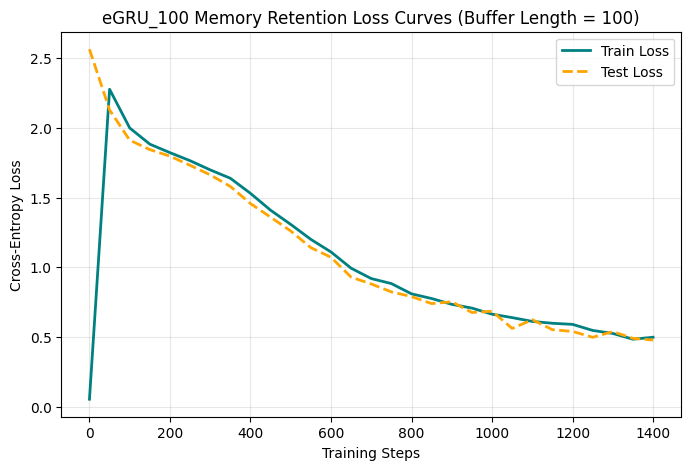

STEP: 1400 | TRAIN LOSS: 0.4976 | TEST LOSS: 0.4773


  0%|          | 0/10 [00:00<?, ?it/s]

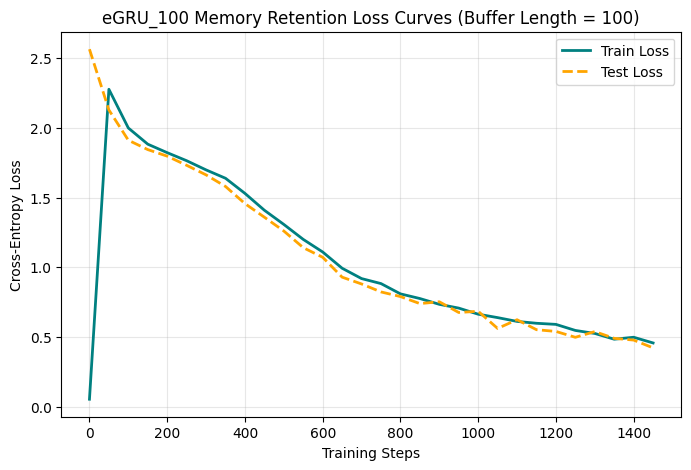

STEP: 1450 | TRAIN LOSS: 0.4567 | TEST LOSS: 0.4214


  0%|          | 0/10 [00:00<?, ?it/s]

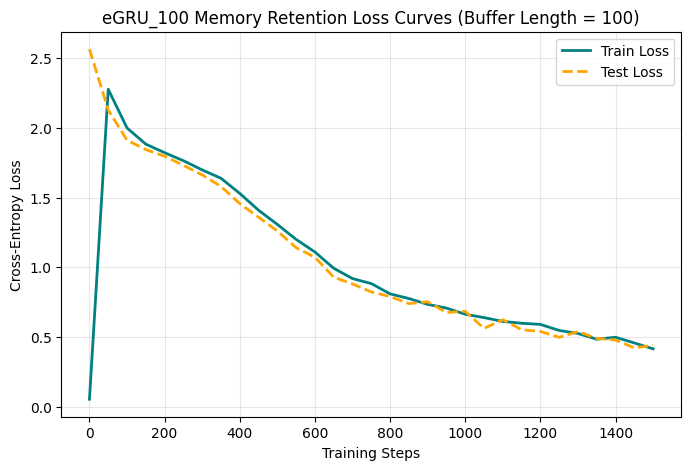

STEP: 1500 | TRAIN LOSS: 0.4145 | TEST LOSS: 0.4397


  0%|          | 0/10 [00:00<?, ?it/s]

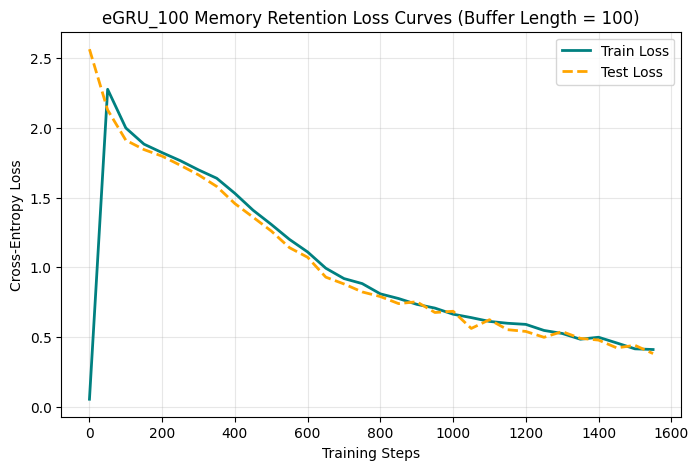

STEP: 1550 | TRAIN LOSS: 0.4095 | TEST LOSS: 0.3805


  0%|          | 0/10 [00:00<?, ?it/s]

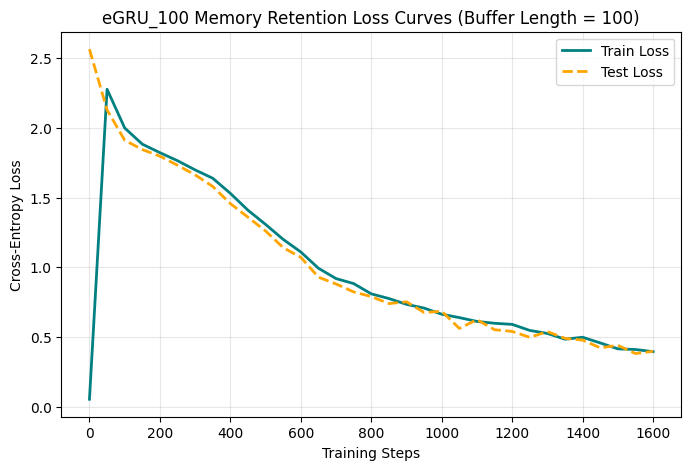

STEP: 1600 | TRAIN LOSS: 0.3941 | TEST LOSS: 0.3965


  0%|          | 0/10 [00:00<?, ?it/s]

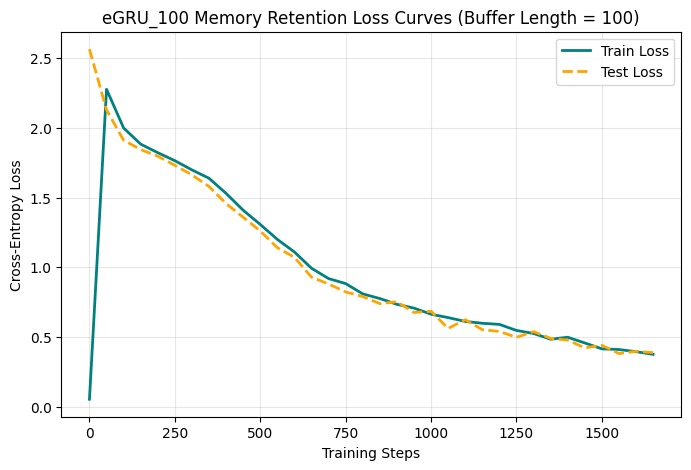

STEP: 1650 | TRAIN LOSS: 0.3748 | TEST LOSS: 0.3872


  0%|          | 0/10 [00:00<?, ?it/s]

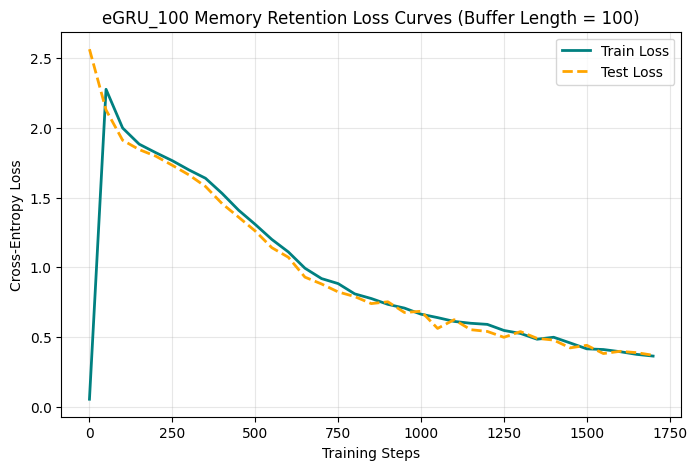

STEP: 1700 | TRAIN LOSS: 0.3625 | TEST LOSS: 0.3684


  0%|          | 0/10 [00:00<?, ?it/s]

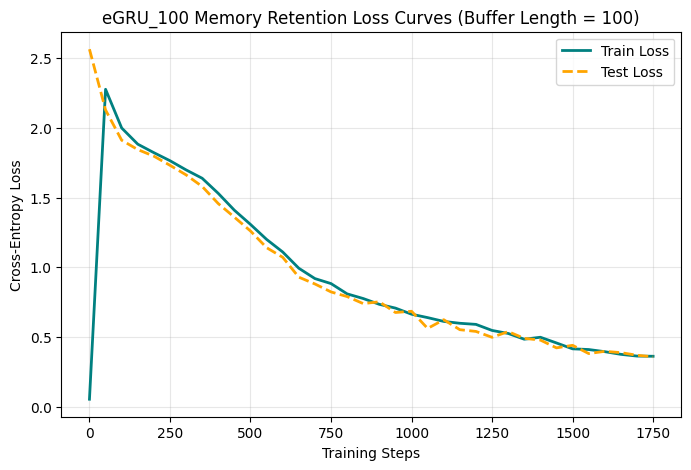

STEP: 1750 | TRAIN LOSS: 0.3611 | TEST LOSS: 0.3573


  0%|          | 0/10 [00:00<?, ?it/s]

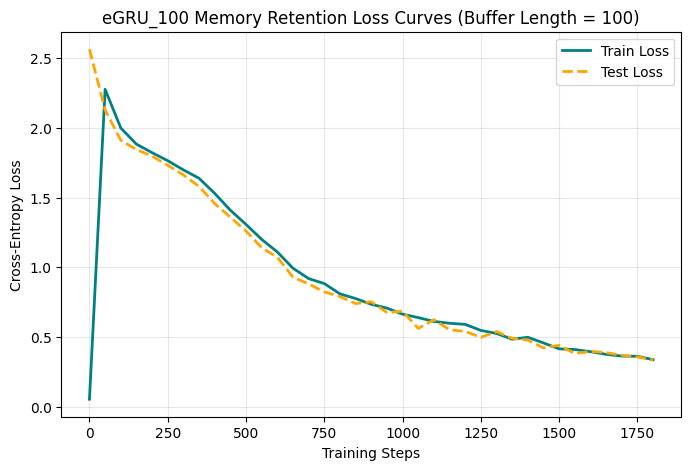

STEP: 1800 | TRAIN LOSS: 0.3364 | TEST LOSS: 0.3333


  0%|          | 0/10 [00:00<?, ?it/s]

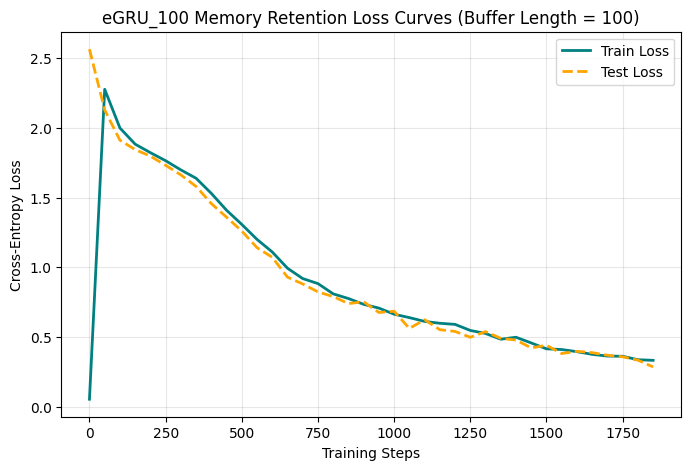

STEP: 1850 | TRAIN LOSS: 0.3319 | TEST LOSS: 0.2845


  0%|          | 0/10 [00:00<?, ?it/s]

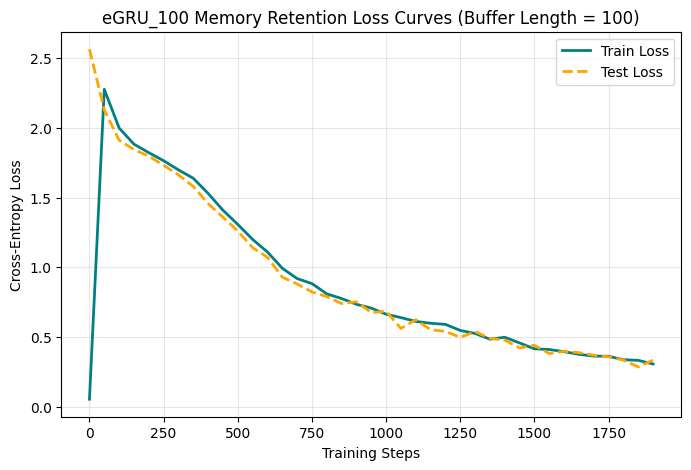

STEP: 1900 | TRAIN LOSS: 0.3055 | TEST LOSS: 0.3337


  0%|          | 0/10 [00:00<?, ?it/s]

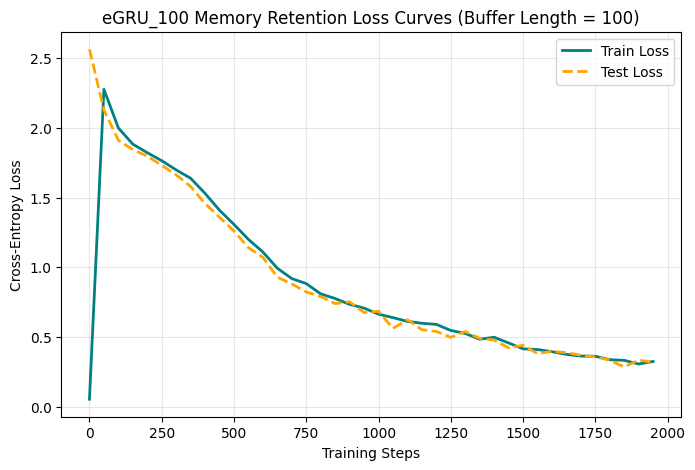

STEP: 1950 | TRAIN LOSS: 0.3238 | TEST LOSS: 0.3172


  0%|          | 0/10 [00:00<?, ?it/s]

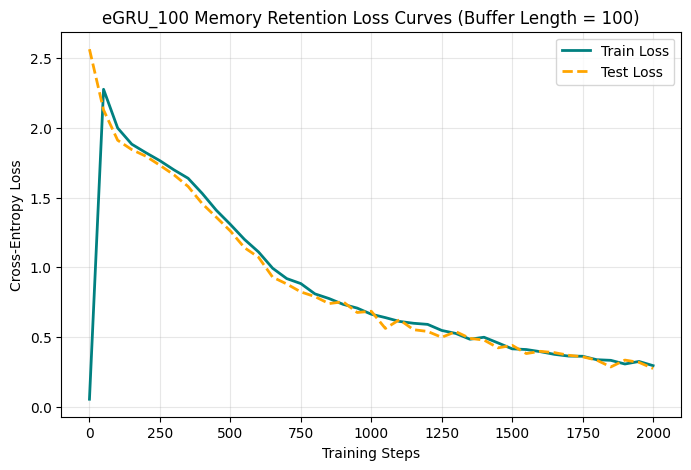

STEP: 2000 | TRAIN LOSS: 0.2937 | TEST LOSS: 0.2733


  0%|          | 0/10 [00:00<?, ?it/s]

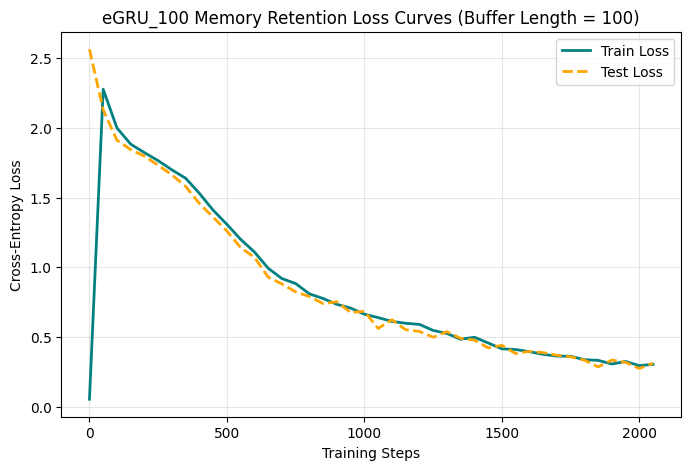

STEP: 2050 | TRAIN LOSS: 0.3034 | TEST LOSS: 0.3117


  0%|          | 0/10 [00:00<?, ?it/s]

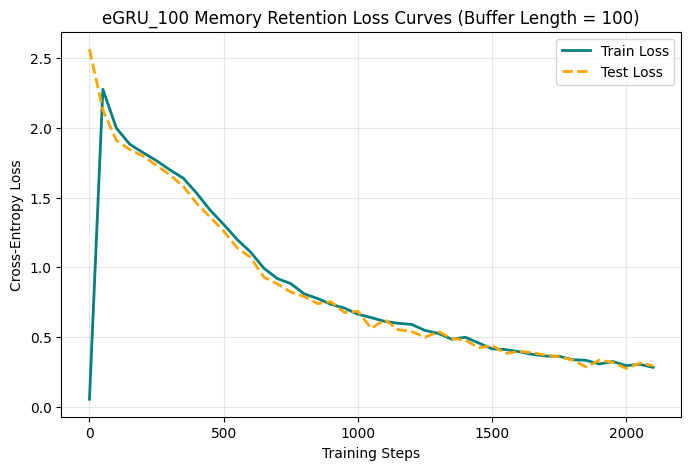

STEP: 2100 | TRAIN LOSS: 0.2814 | TEST LOSS: 0.2931


  0%|          | 0/10 [00:00<?, ?it/s]

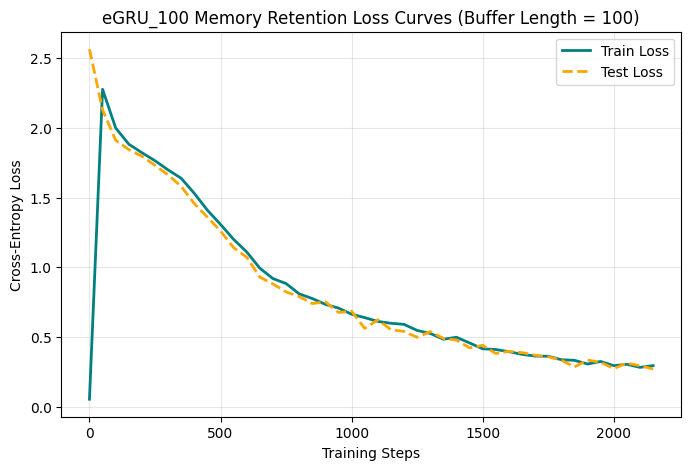

STEP: 2150 | TRAIN LOSS: 0.2939 | TEST LOSS: 0.2703


  0%|          | 0/10 [00:00<?, ?it/s]

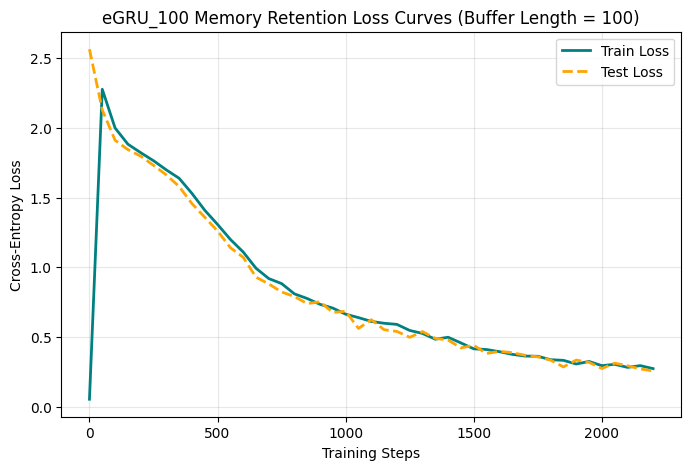

STEP: 2200 | TRAIN LOSS: 0.2724 | TEST LOSS: 0.2561


  0%|          | 0/10 [00:00<?, ?it/s]

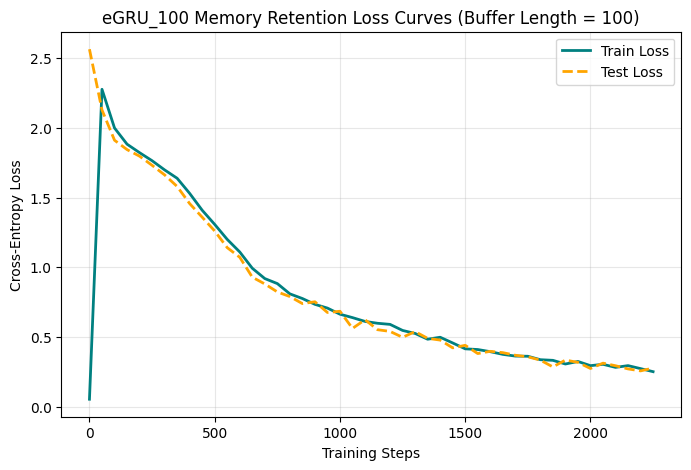

STEP: 2250 | TRAIN LOSS: 0.2505 | TEST LOSS: 0.2767


  0%|          | 0/10 [00:00<?, ?it/s]

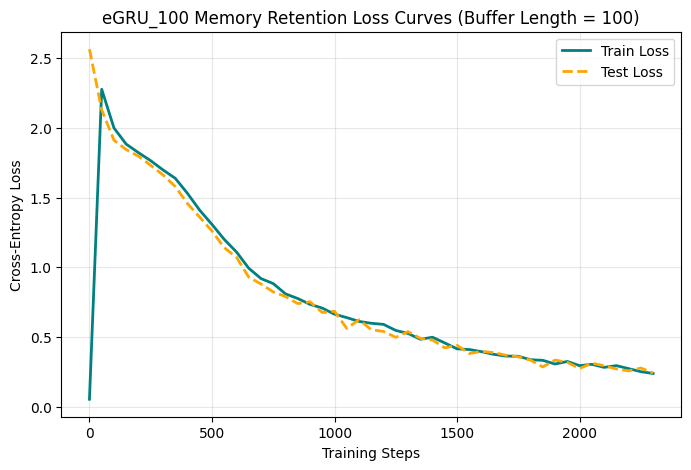

STEP: 2300 | TRAIN LOSS: 0.2375 | TEST LOSS: 0.2412


  0%|          | 0/10 [00:00<?, ?it/s]

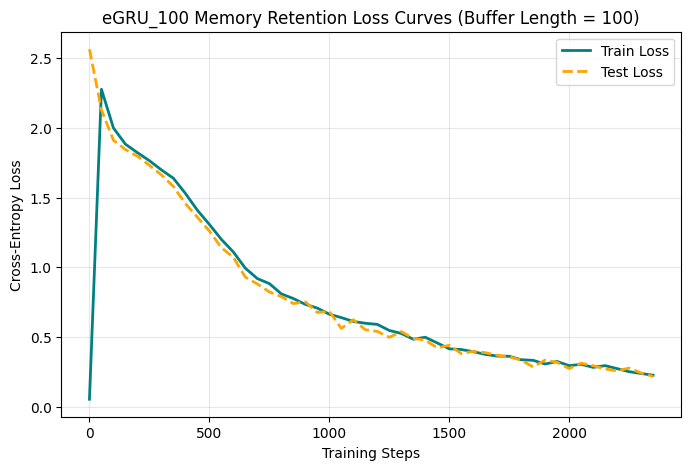

STEP: 2350 | TRAIN LOSS: 0.2252 | TEST LOSS: 0.2163


  0%|          | 0/10 [00:00<?, ?it/s]

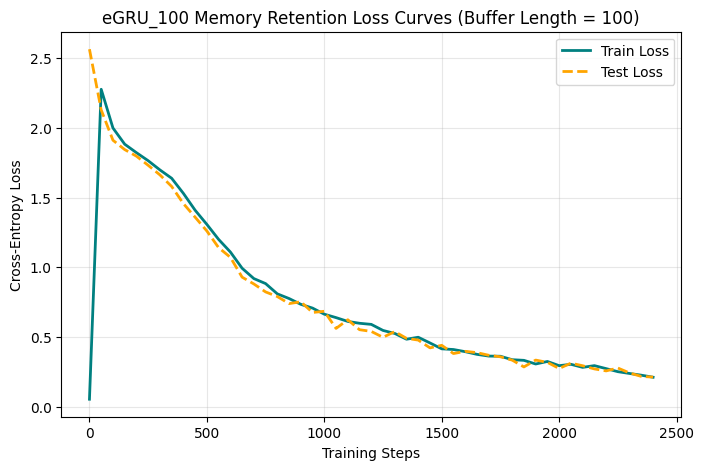

STEP: 2400 | TRAIN LOSS: 0.2105 | TEST LOSS: 0.2117


  0%|          | 0/10 [00:00<?, ?it/s]

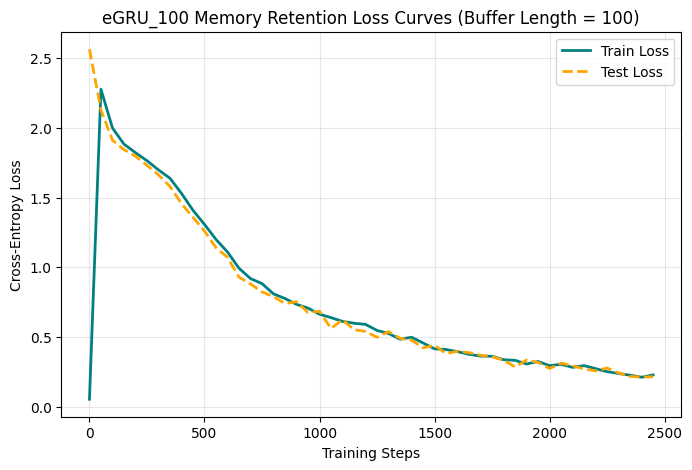

STEP: 2450 | TRAIN LOSS: 0.2270 | TEST LOSS: 0.2144


  0%|          | 0/10 [00:00<?, ?it/s]

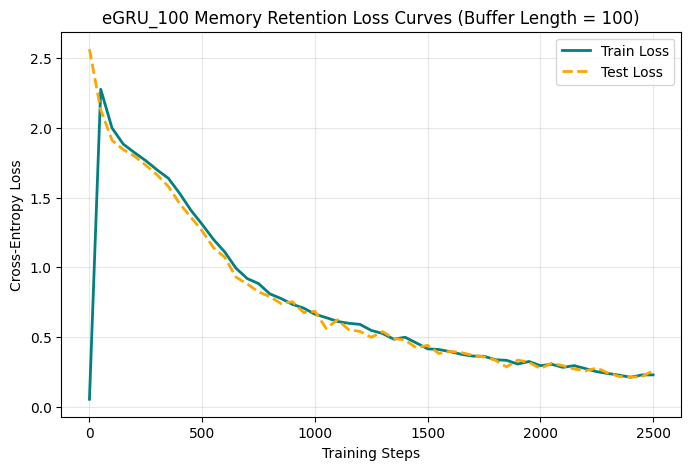

STEP: 2500 | TRAIN LOSS: 0.2274 | TEST LOSS: 0.2570


  0%|          | 0/10 [00:00<?, ?it/s]

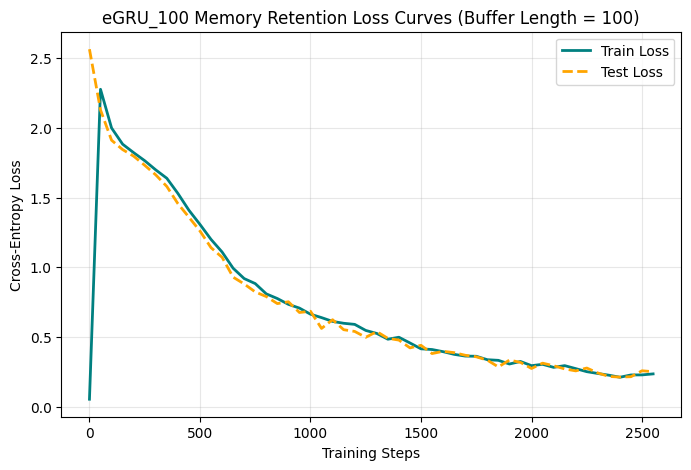

STEP: 2550 | TRAIN LOSS: 0.2346 | TEST LOSS: 0.2502


  0%|          | 0/10 [00:00<?, ?it/s]

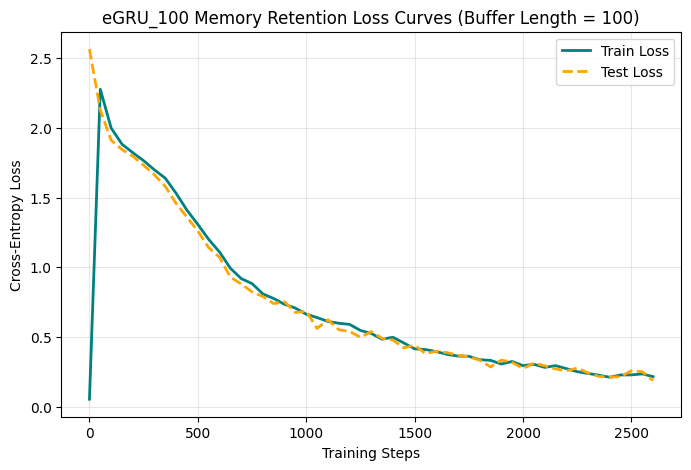

STEP: 2600 | TRAIN LOSS: 0.2149 | TEST LOSS: 0.1864


  0%|          | 0/10 [00:00<?, ?it/s]

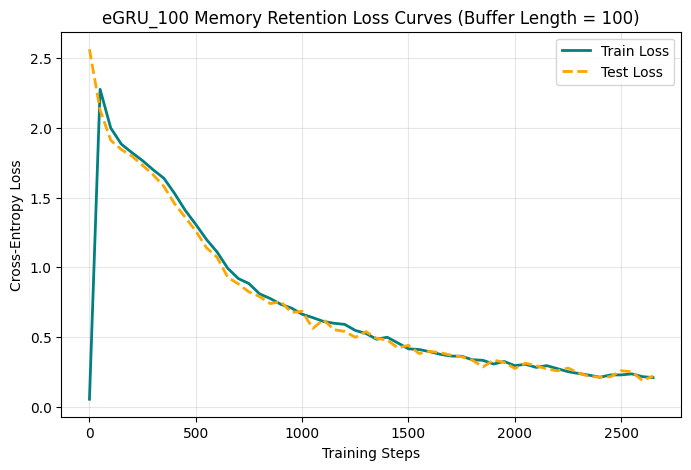

STEP: 2650 | TRAIN LOSS: 0.2082 | TEST LOSS: 0.2196


  0%|          | 0/10 [00:00<?, ?it/s]

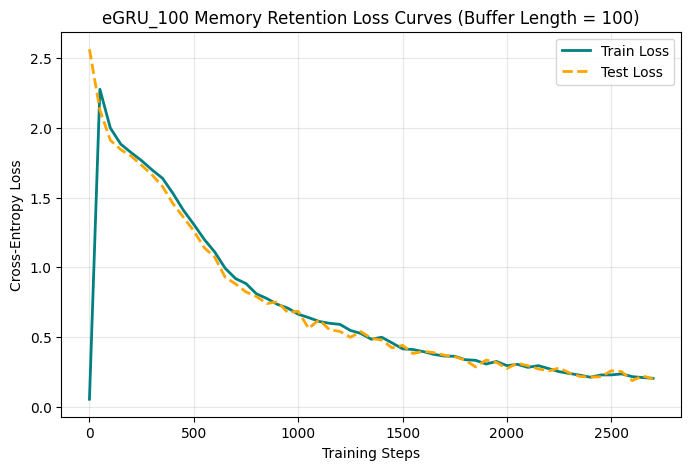

STEP: 2700 | TRAIN LOSS: 0.2029 | TEST LOSS: 0.1991


  0%|          | 0/10 [00:00<?, ?it/s]

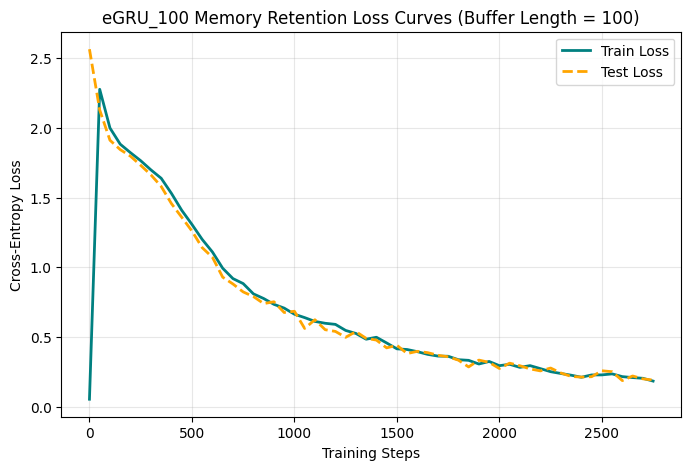

STEP: 2750 | TRAIN LOSS: 0.1830 | TEST LOSS: 0.1900


  0%|          | 0/10 [00:00<?, ?it/s]

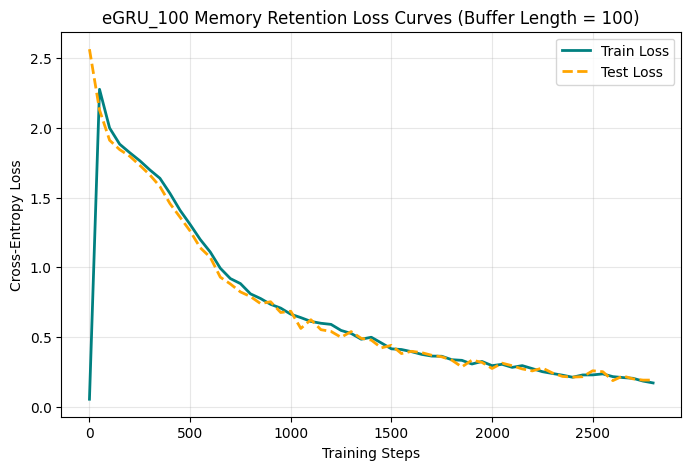

STEP: 2800 | TRAIN LOSS: 0.1697 | TEST LOSS: 0.1900


  0%|          | 0/10 [00:00<?, ?it/s]

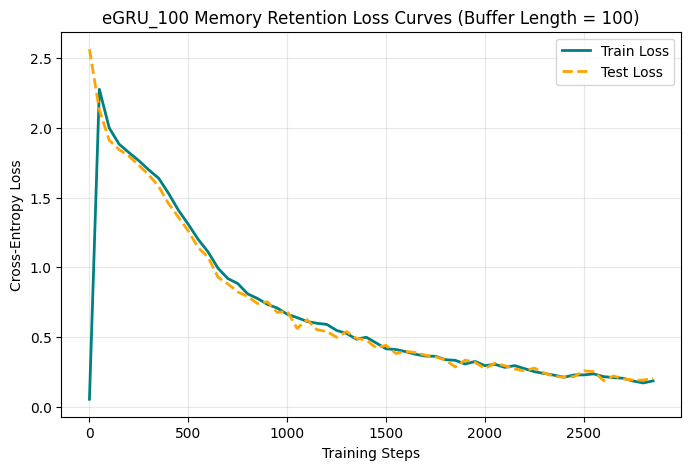

STEP: 2850 | TRAIN LOSS: 0.1844 | TEST LOSS: 0.2026


  0%|          | 0/10 [00:00<?, ?it/s]

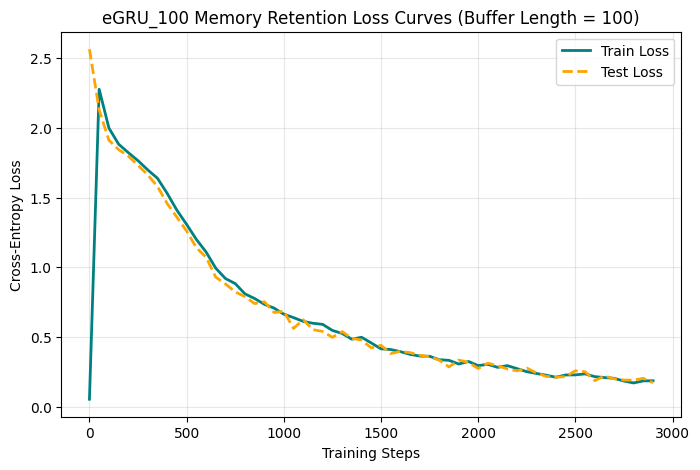

STEP: 2900 | TRAIN LOSS: 0.1851 | TEST LOSS: 0.1711


  0%|          | 0/10 [00:00<?, ?it/s]

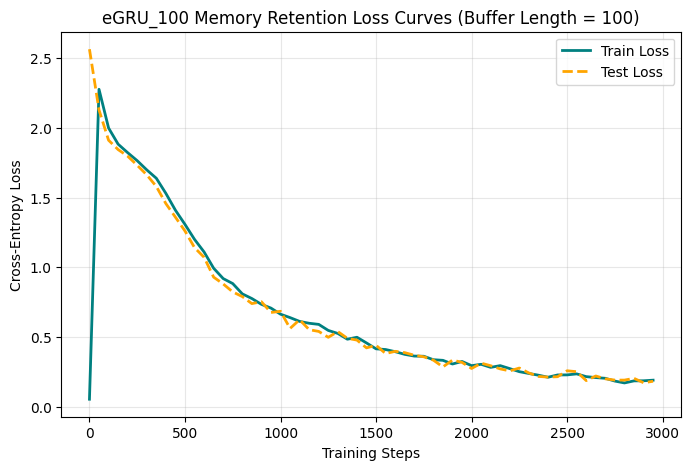

STEP: 2950 | TRAIN LOSS: 0.1894 | TEST LOSS: 0.1817


  0%|          | 0/10 [00:00<?, ?it/s]

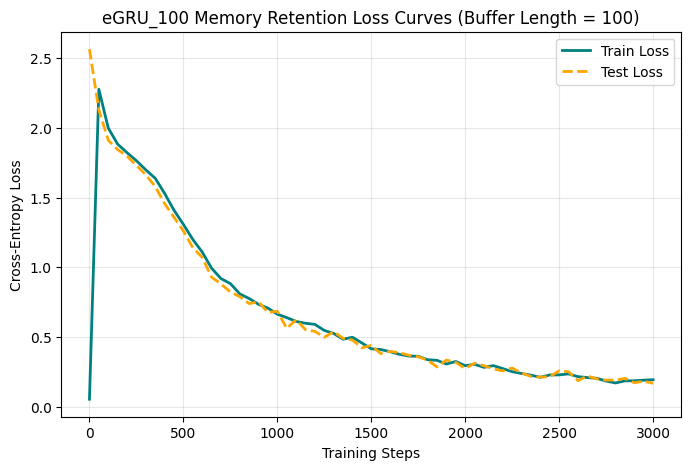

STEP: 3000 | TRAIN LOSS: 0.1927 | TEST LOSS: 0.1675


  0%|          | 0/10 [00:00<?, ?it/s]

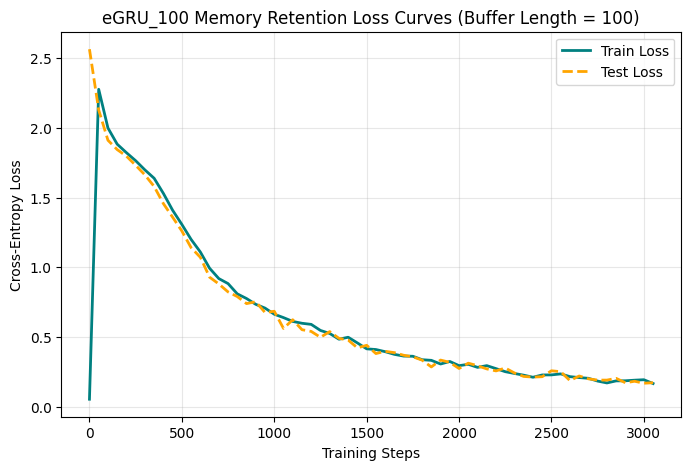

STEP: 3050 | TRAIN LOSS: 0.1654 | TEST LOSS: 0.1712


  0%|          | 0/10 [00:00<?, ?it/s]

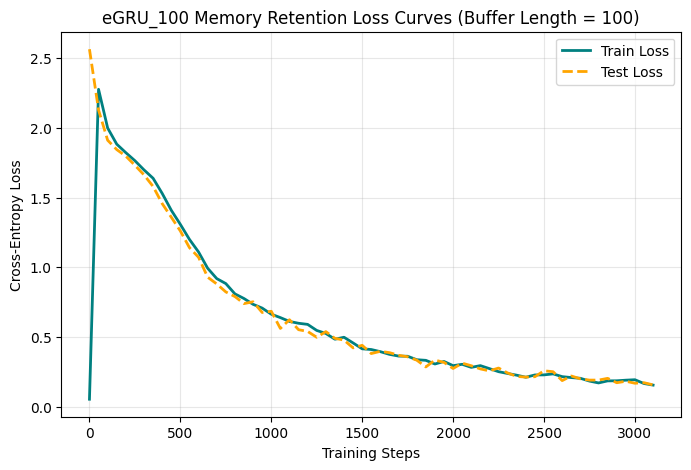

STEP: 3100 | TRAIN LOSS: 0.1541 | TEST LOSS: 0.1557


  0%|          | 0/10 [00:00<?, ?it/s]

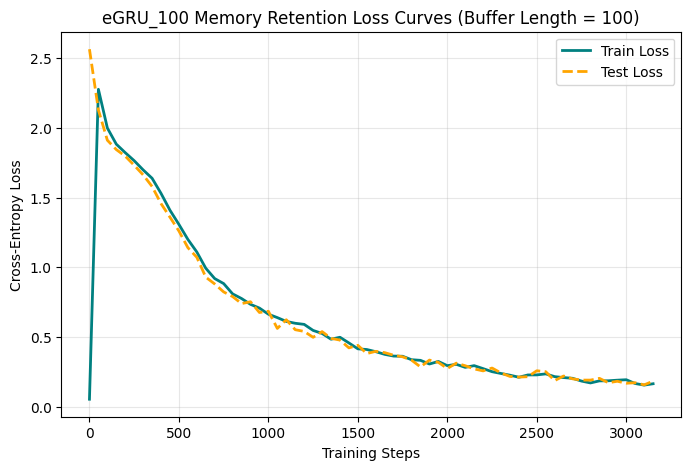

STEP: 3150 | TRAIN LOSS: 0.1638 | TEST LOSS: 0.1827


  0%|          | 0/10 [00:00<?, ?it/s]

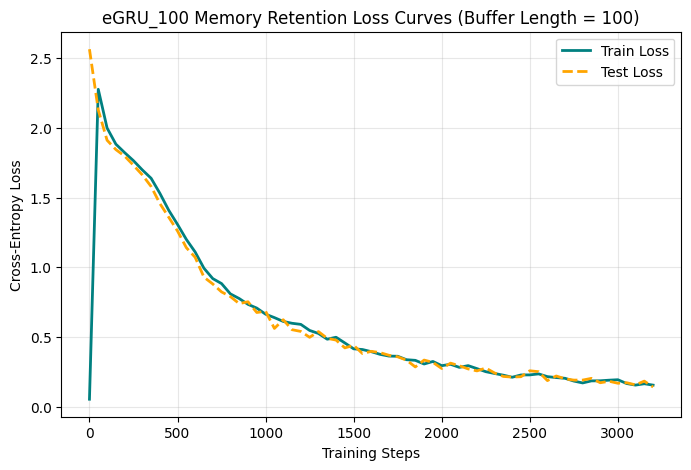

STEP: 3200 | TRAIN LOSS: 0.1540 | TEST LOSS: 0.1402


  0%|          | 0/10 [00:00<?, ?it/s]

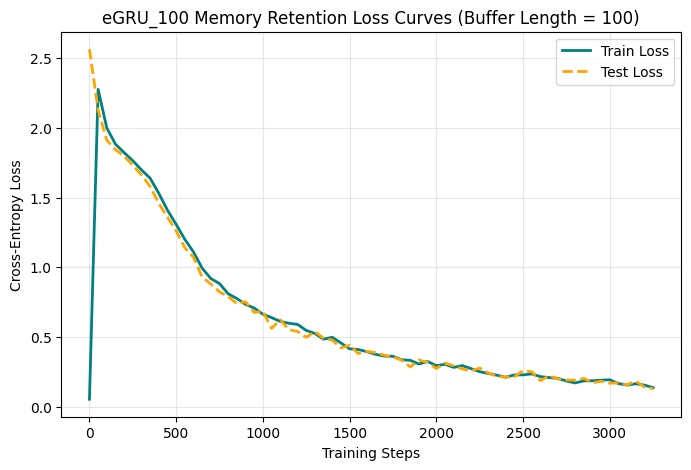

STEP: 3250 | TRAIN LOSS: 0.1358 | TEST LOSS: 0.1285


  0%|          | 0/10 [00:00<?, ?it/s]

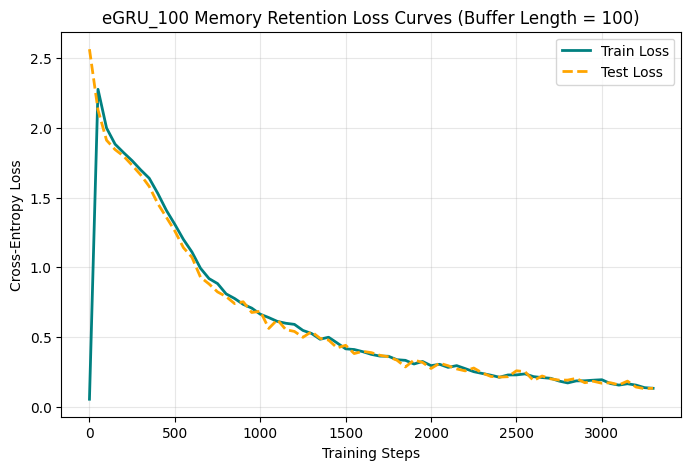

STEP: 3300 | TRAIN LOSS: 0.1311 | TEST LOSS: 0.1319


  0%|          | 0/10 [00:00<?, ?it/s]

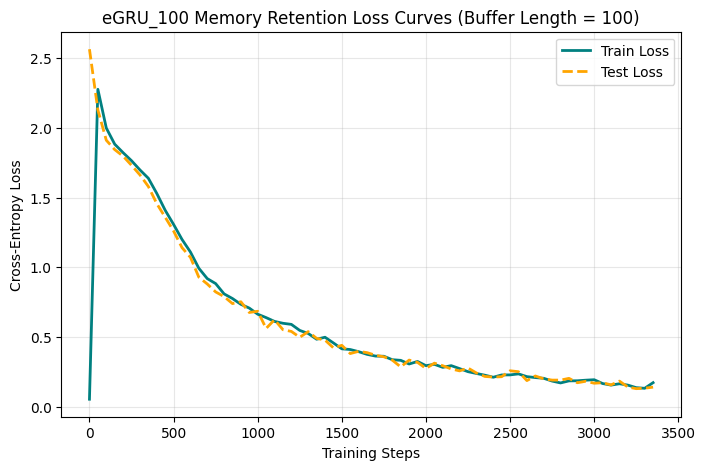

STEP: 3350 | TRAIN LOSS: 0.1717 | TEST LOSS: 0.1394


  0%|          | 0/10 [00:00<?, ?it/s]

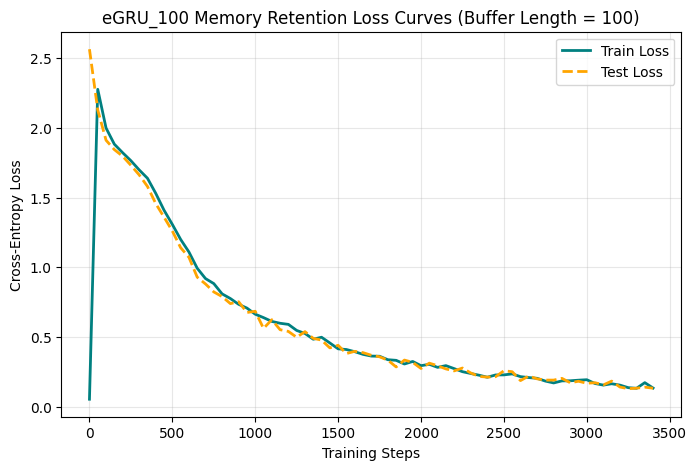

STEP: 3400 | TRAIN LOSS: 0.1330 | TEST LOSS: 0.1317


  0%|          | 0/10 [00:00<?, ?it/s]

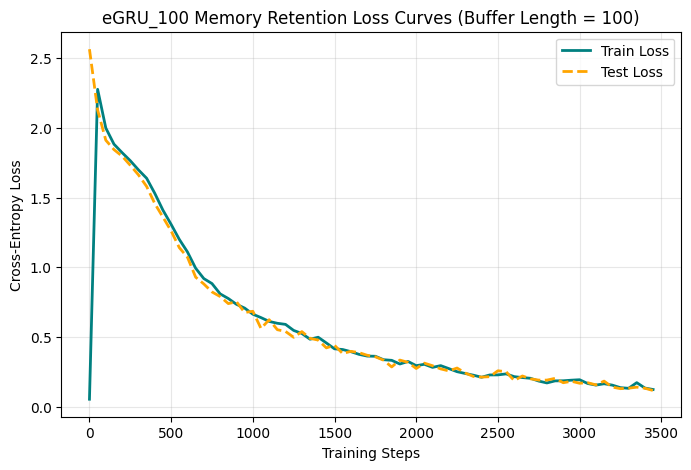

STEP: 3450 | TRAIN LOSS: 0.1225 | TEST LOSS: 0.1151


  0%|          | 0/10 [00:00<?, ?it/s]

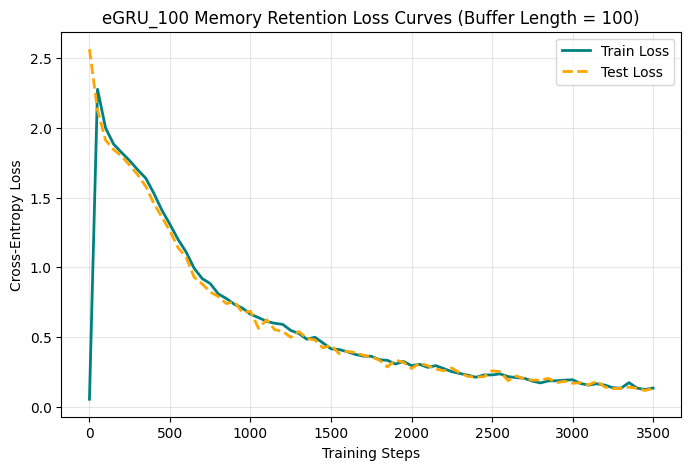

STEP: 3500 | TRAIN LOSS: 0.1329 | TEST LOSS: 0.1311


  0%|          | 0/10 [00:00<?, ?it/s]

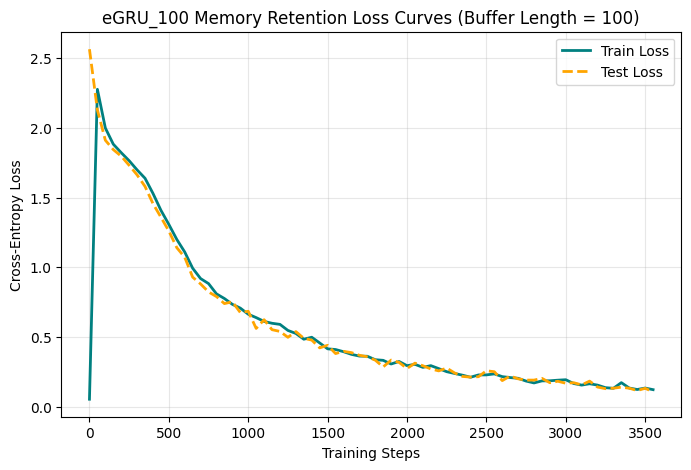

STEP: 3550 | TRAIN LOSS: 0.1214 | TEST LOSS: 0.1058


  0%|          | 0/10 [00:00<?, ?it/s]

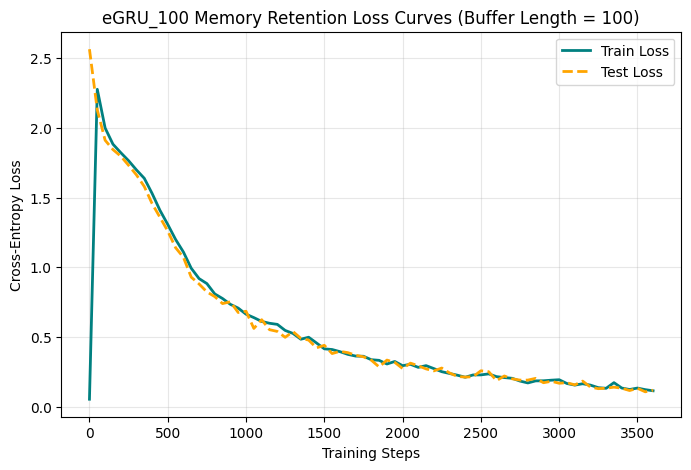

STEP: 3600 | TRAIN LOSS: 0.1133 | TEST LOSS: 0.1173


  0%|          | 0/10 [00:00<?, ?it/s]

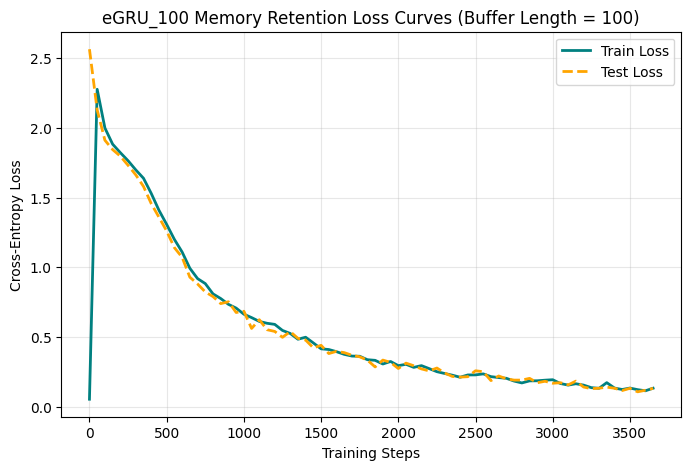

STEP: 3650 | TRAIN LOSS: 0.1317 | TEST LOSS: 0.1304


  0%|          | 0/10 [00:00<?, ?it/s]

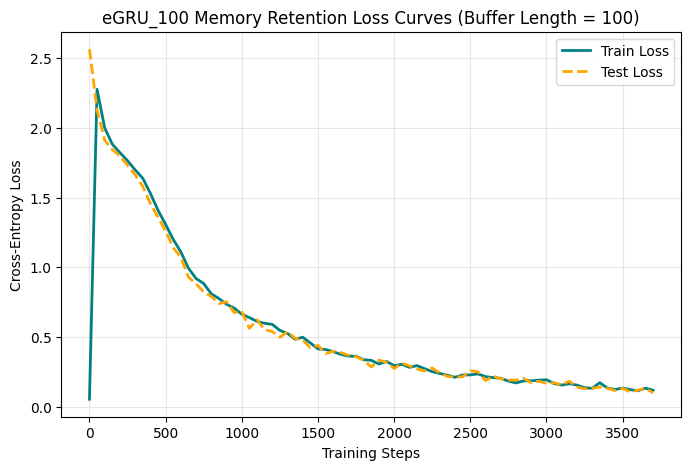

STEP: 3700 | TRAIN LOSS: 0.1177 | TEST LOSS: 0.0985


  0%|          | 0/10 [00:00<?, ?it/s]

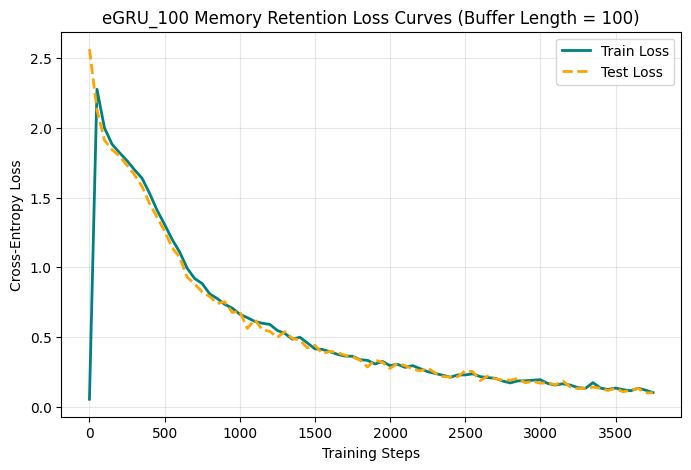

STEP: 3750 | TRAIN LOSS: 0.1005 | TEST LOSS: 0.0988


  0%|          | 0/10 [00:00<?, ?it/s]

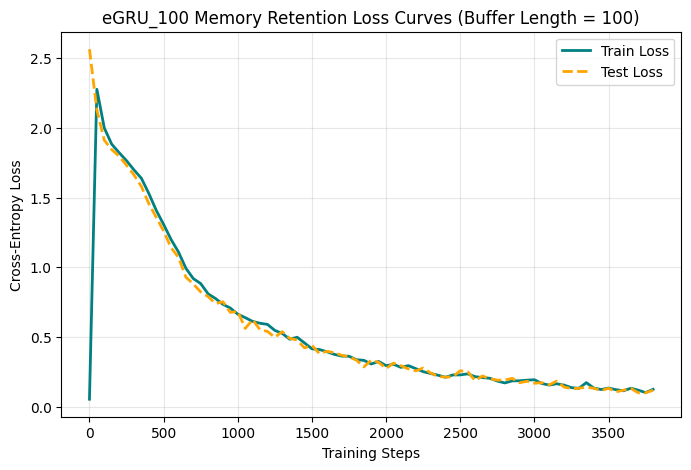

STEP: 3800 | TRAIN LOSS: 0.1237 | TEST LOSS: 0.1173


  0%|          | 0/10 [00:00<?, ?it/s]

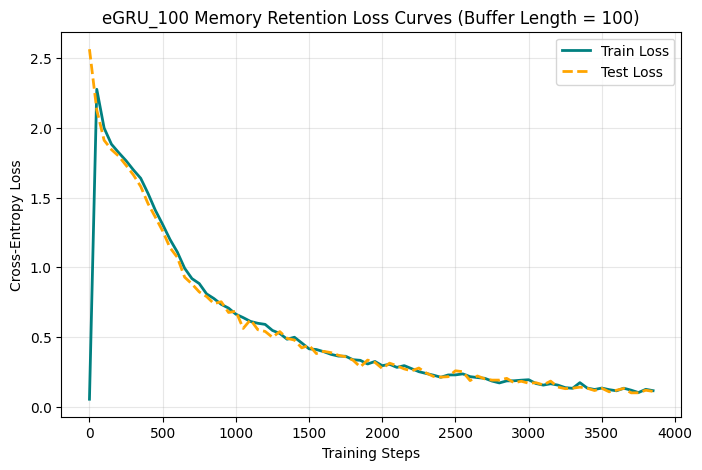

STEP: 3850 | TRAIN LOSS: 0.1141 | TEST LOSS: 0.1087


  0%|          | 0/10 [00:00<?, ?it/s]

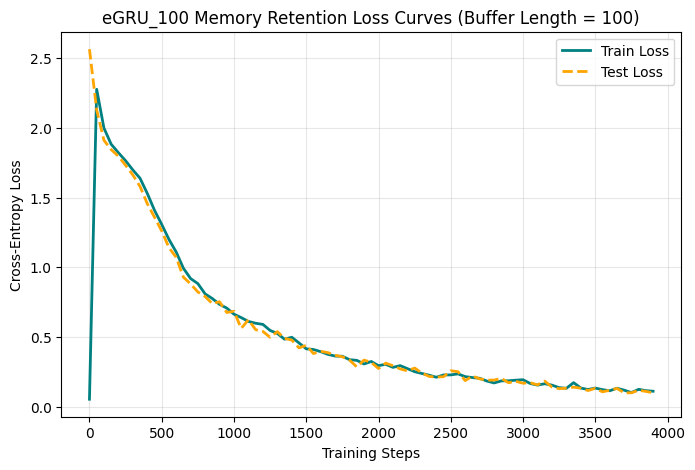

STEP: 3900 | TRAIN LOSS: 0.1101 | TEST LOSS: 0.0990


  0%|          | 0/10 [00:00<?, ?it/s]

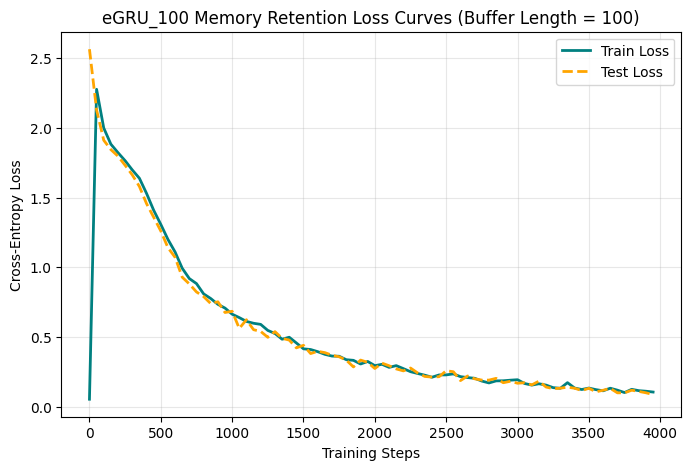

STEP: 3950 | TRAIN LOSS: 0.1043 | TEST LOSS: 0.0861


  0%|          | 0/10 [00:00<?, ?it/s]

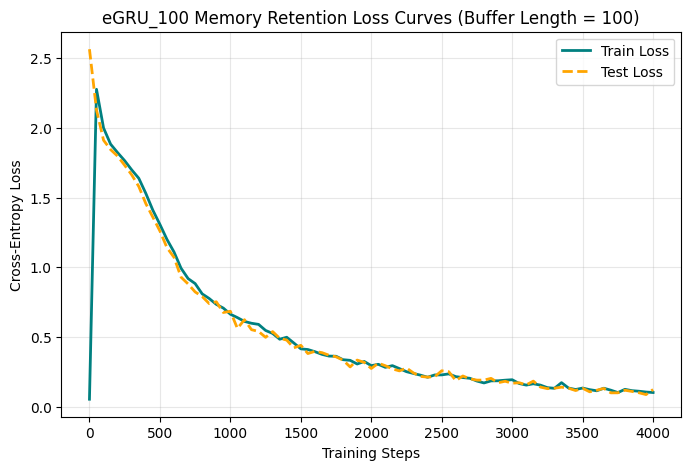

STEP: 4000 | TRAIN LOSS: 0.1009 | TEST LOSS: 0.1223


  0%|          | 0/10 [00:00<?, ?it/s]

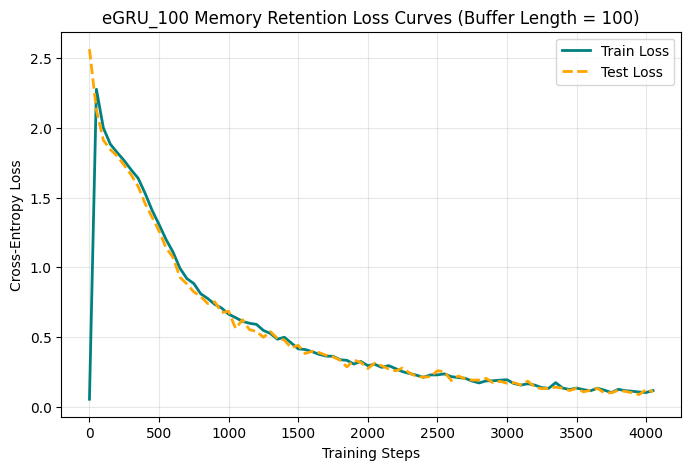

STEP: 4050 | TRAIN LOSS: 0.1149 | TEST LOSS: 0.1061


  0%|          | 0/10 [00:00<?, ?it/s]

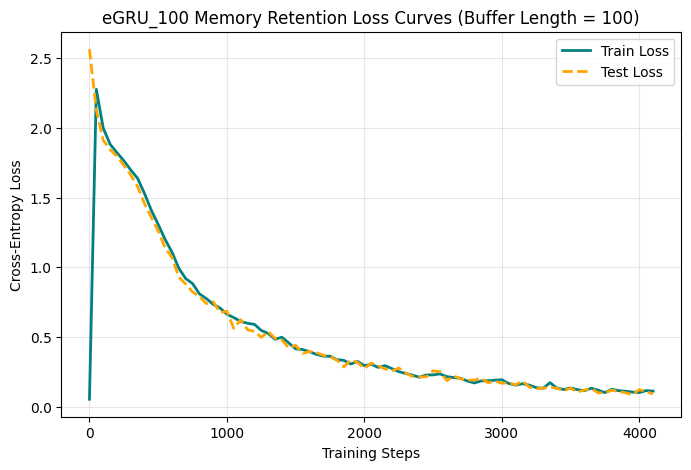

STEP: 4100 | TRAIN LOSS: 0.1108 | TEST LOSS: 0.0909


  0%|          | 0/10 [00:00<?, ?it/s]

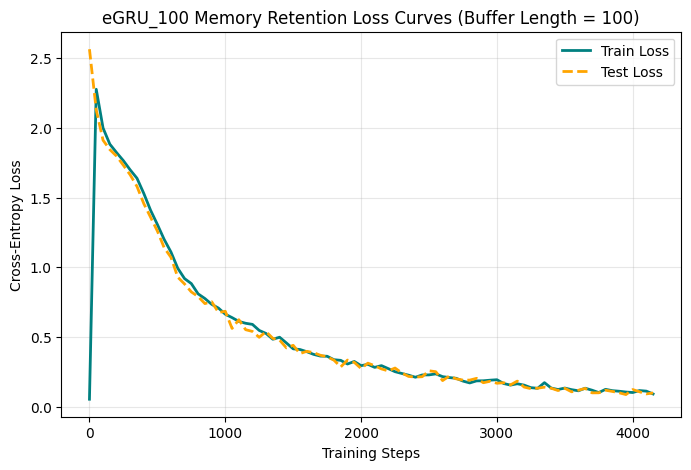

STEP: 4150 | TRAIN LOSS: 0.0905 | TEST LOSS: 0.0977


  0%|          | 0/10 [00:00<?, ?it/s]

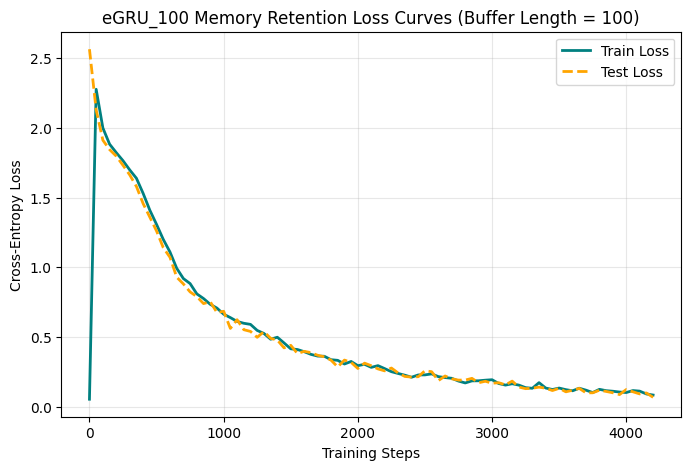

STEP: 4200 | TRAIN LOSS: 0.0827 | TEST LOSS: 0.0664


  0%|          | 0/10 [00:00<?, ?it/s]

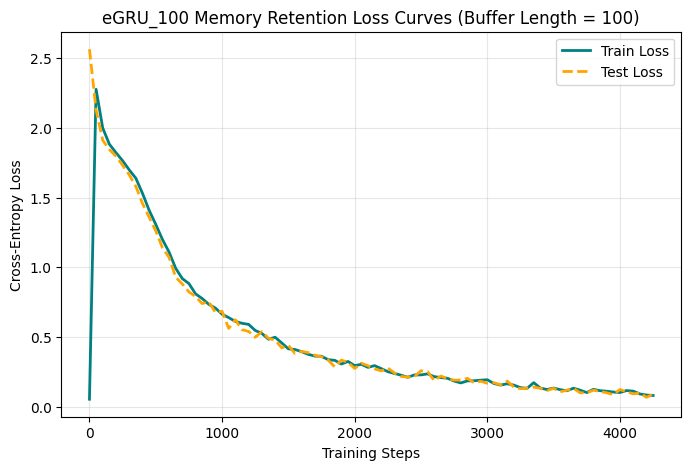

STEP: 4250 | TRAIN LOSS: 0.0793 | TEST LOSS: 0.0893


  0%|          | 0/10 [00:00<?, ?it/s]

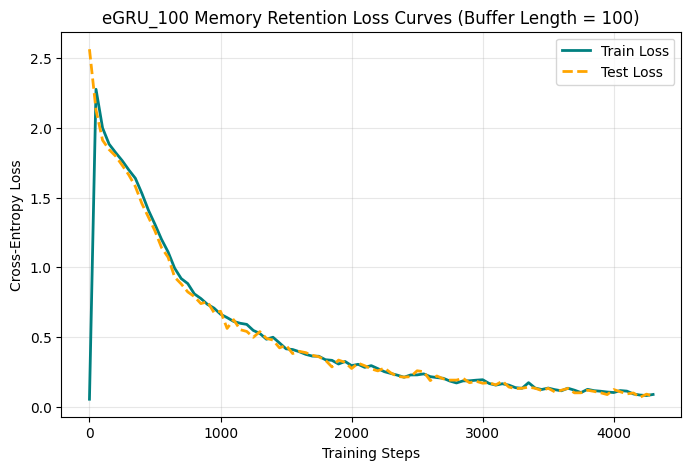

STEP: 4300 | TRAIN LOSS: 0.0869 | TEST LOSS: 0.0749


  0%|          | 0/10 [00:00<?, ?it/s]

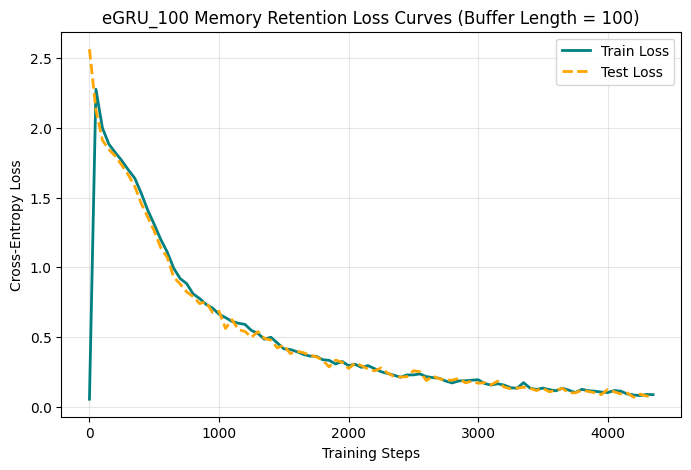

STEP: 4350 | TRAIN LOSS: 0.0855 | TEST LOSS: 0.0771


  0%|          | 0/10 [00:00<?, ?it/s]

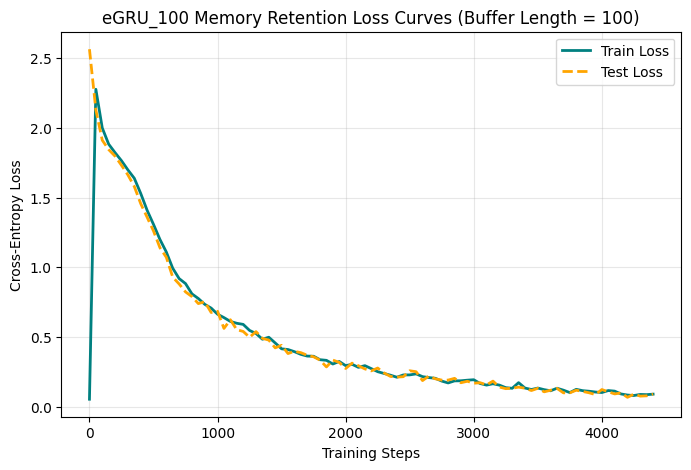

STEP: 4400 | TRAIN LOSS: 0.0892 | TEST LOSS: 0.0895


  0%|          | 0/10 [00:00<?, ?it/s]

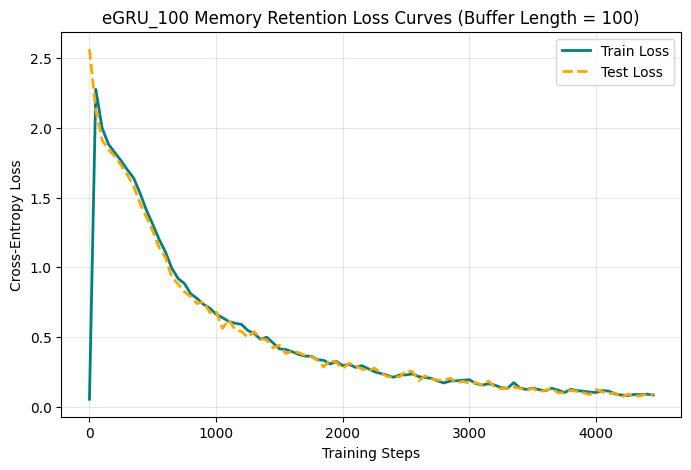

STEP: 4450 | TRAIN LOSS: 0.0830 | TEST LOSS: 0.0837


  0%|          | 0/10 [00:00<?, ?it/s]

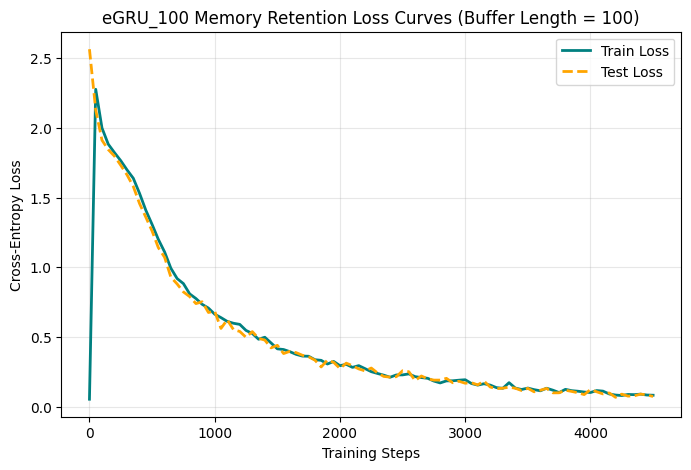

STEP: 4500 | TRAIN LOSS: 0.0815 | TEST LOSS: 0.0724


  0%|          | 0/10 [00:00<?, ?it/s]

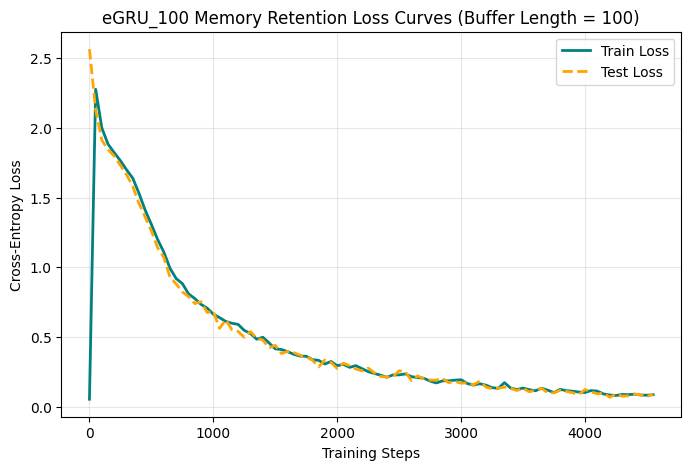

STEP: 4550 | TRAIN LOSS: 0.0853 | TEST LOSS: 0.0895


  0%|          | 0/10 [00:00<?, ?it/s]

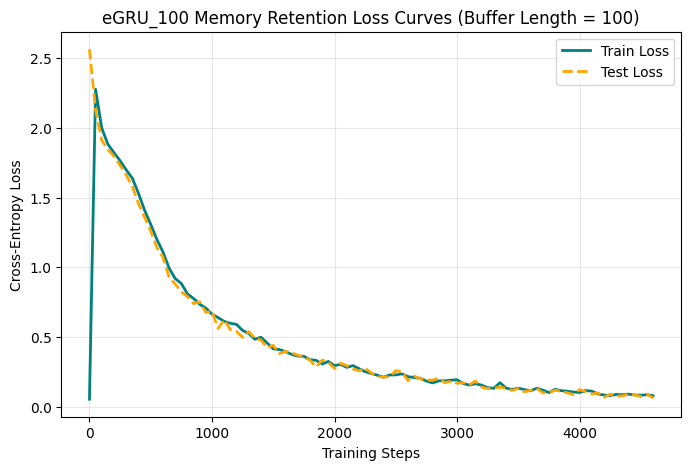

STEP: 4600 | TRAIN LOSS: 0.0775 | TEST LOSS: 0.0610


  0%|          | 0/10 [00:00<?, ?it/s]

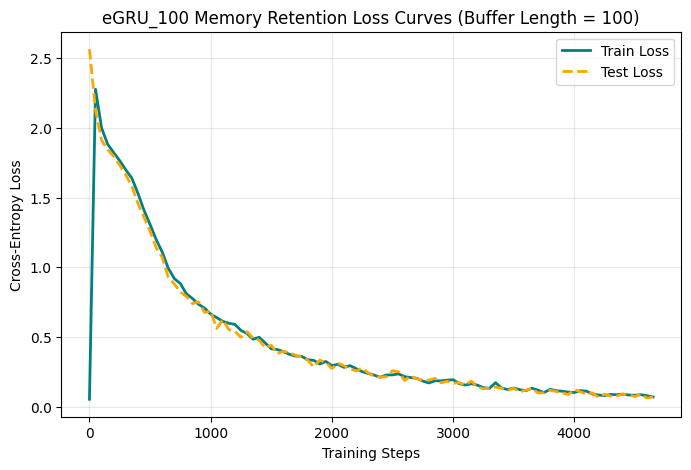

STEP: 4650 | TRAIN LOSS: 0.0691 | TEST LOSS: 0.0700


  0%|          | 0/10 [00:00<?, ?it/s]

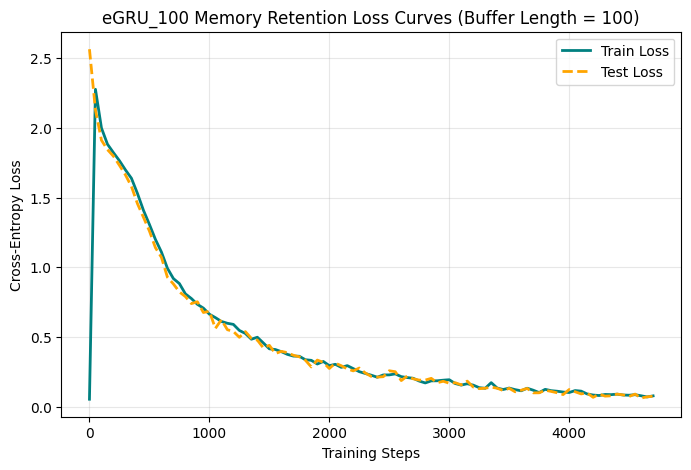

STEP: 4700 | TRAIN LOSS: 0.0768 | TEST LOSS: 0.0741


  0%|          | 0/10 [00:00<?, ?it/s]

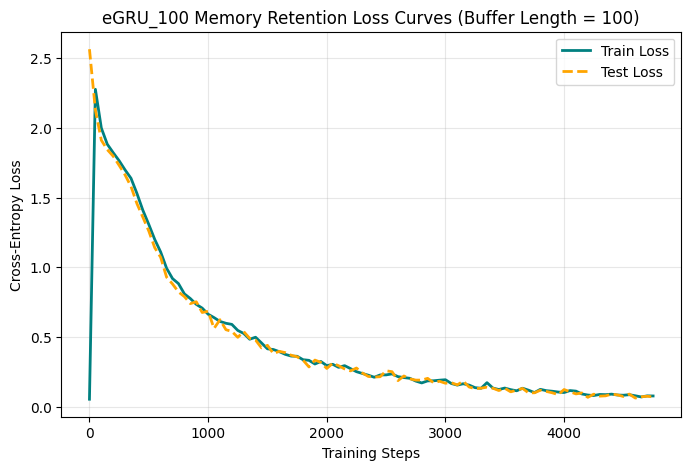

STEP: 4750 | TRAIN LOSS: 0.0761 | TEST LOSS: 0.0695


  0%|          | 0/10 [00:00<?, ?it/s]

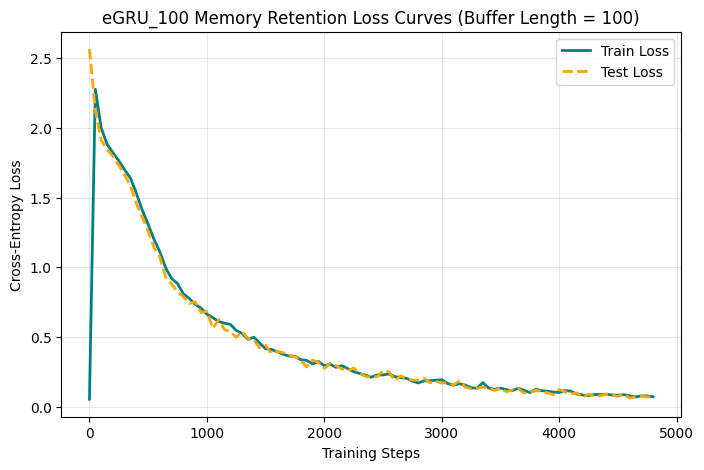

STEP: 4800 | TRAIN LOSS: 0.0703 | TEST LOSS: 0.0666


  0%|          | 0/10 [00:00<?, ?it/s]

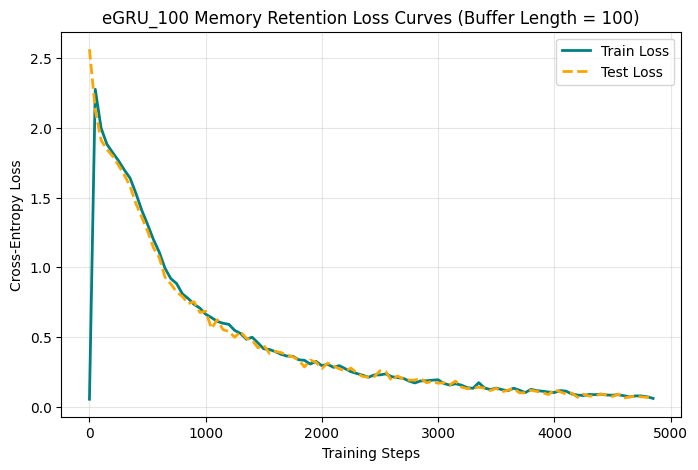

STEP: 4850 | TRAIN LOSS: 0.0586 | TEST LOSS: 0.0607


  0%|          | 0/10 [00:00<?, ?it/s]

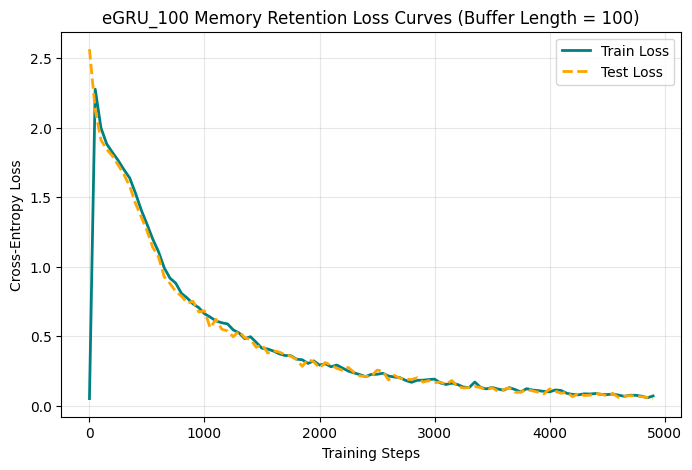

STEP: 4900 | TRAIN LOSS: 0.0716 | TEST LOSS: 0.0481


  0%|          | 0/10 [00:00<?, ?it/s]

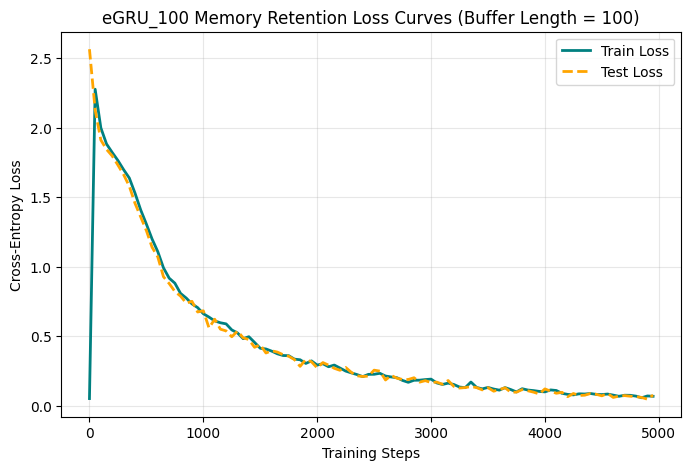

STEP: 4950 | TRAIN LOSS: 0.0693 | TEST LOSS: 0.0780


  0%|          | 0/10 [00:00<?, ?it/s]

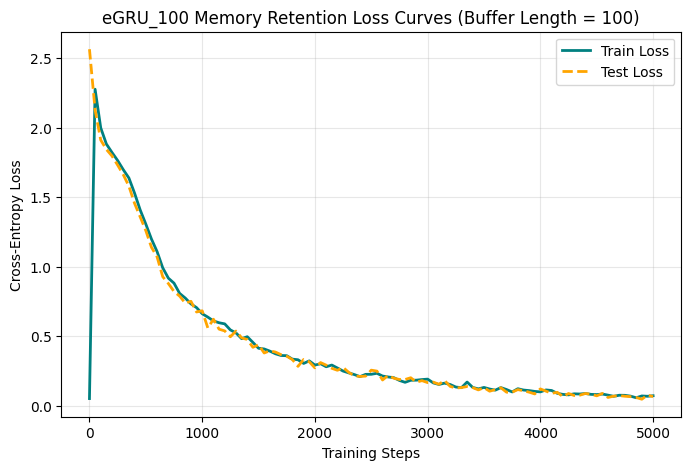

STEP: 5000 | TRAIN LOSS: 0.0731 | TEST LOSS: 0.0664


  0%|          | 0/10 [00:00<?, ?it/s]

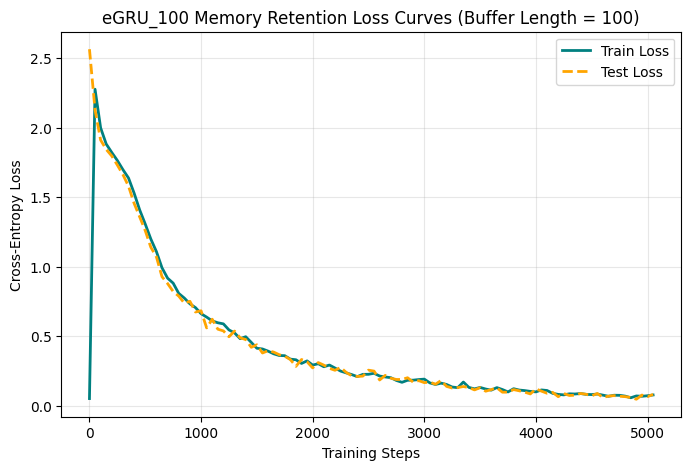

STEP: 5050 | TRAIN LOSS: 0.0787 | TEST LOSS: 0.0830


  0%|          | 0/10 [00:00<?, ?it/s]

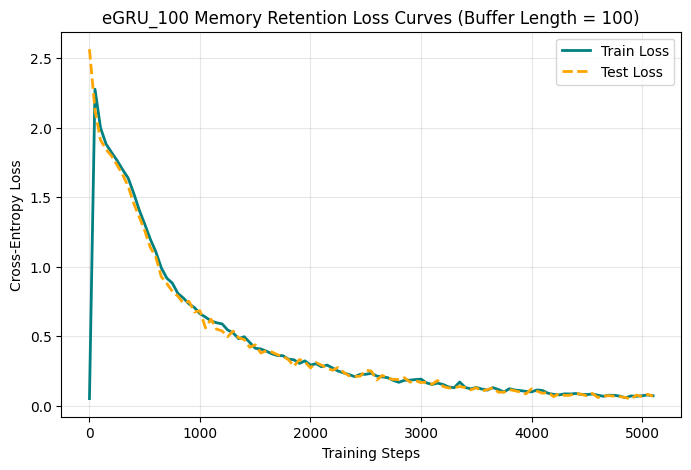

STEP: 5100 | TRAIN LOSS: 0.0728 | TEST LOSS: 0.0695


  0%|          | 0/10 [00:00<?, ?it/s]

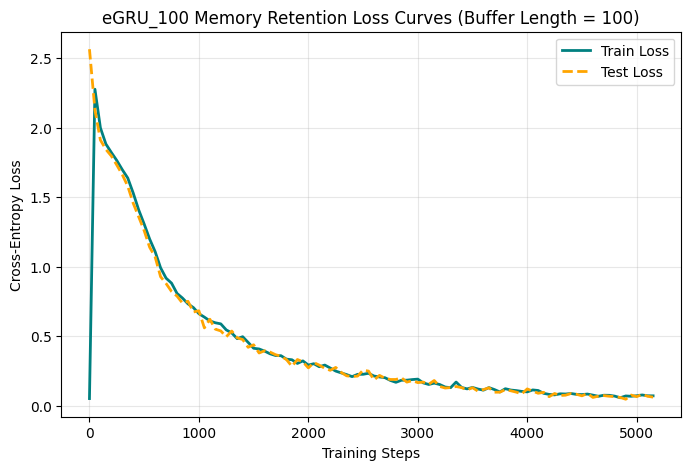

STEP: 5150 | TRAIN LOSS: 0.0724 | TEST LOSS: 0.0629


  0%|          | 0/10 [00:00<?, ?it/s]

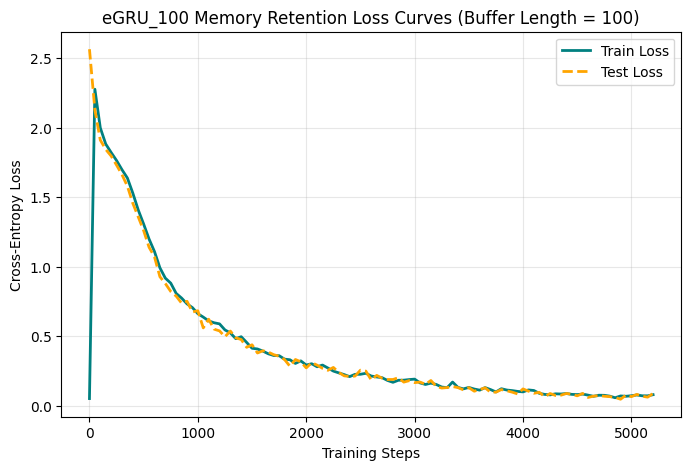

STEP: 5200 | TRAIN LOSS: 0.0806 | TEST LOSS: 0.0900


  0%|          | 0/10 [00:00<?, ?it/s]

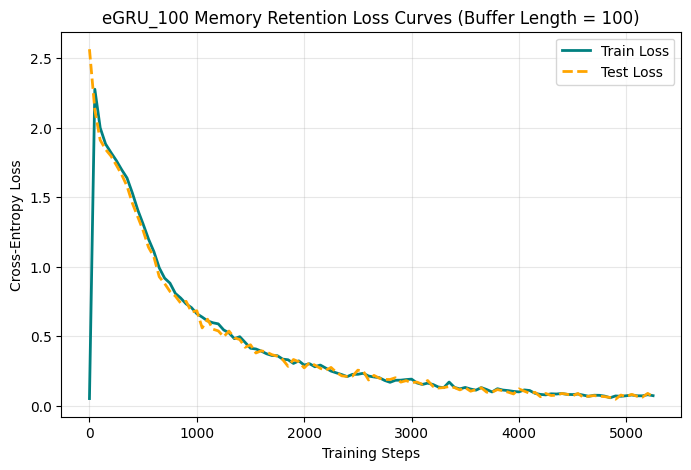

STEP: 5250 | TRAIN LOSS: 0.0736 | TEST LOSS: 0.0656


  0%|          | 0/10 [00:00<?, ?it/s]

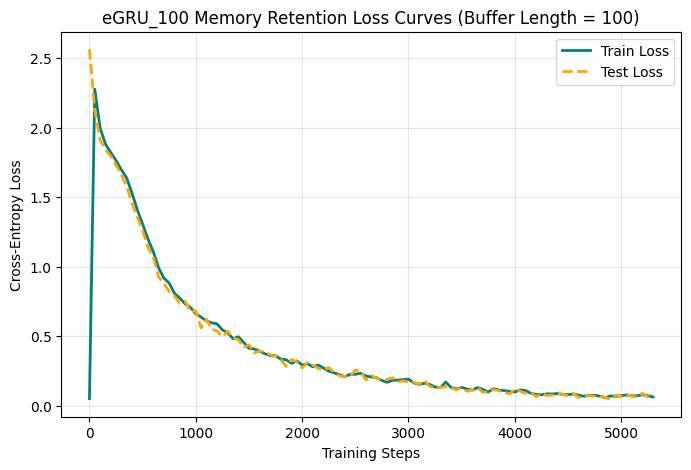

STEP: 5300 | TRAIN LOSS: 0.0644 | TEST LOSS: 0.0632


  0%|          | 0/10 [00:00<?, ?it/s]

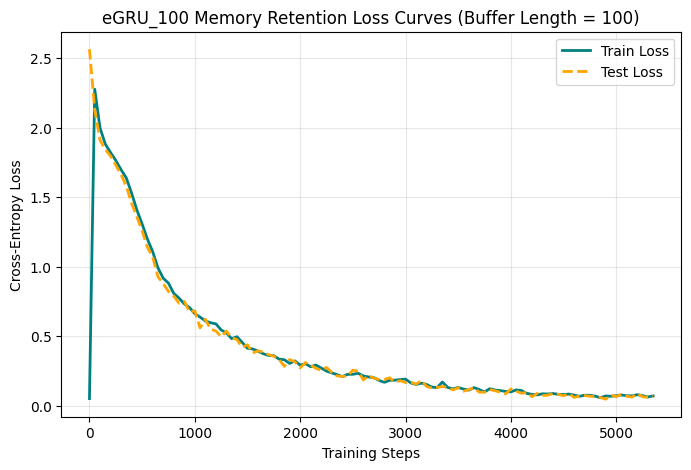

STEP: 5350 | TRAIN LOSS: 0.0715 | TEST LOSS: 0.0687


  0%|          | 0/10 [00:00<?, ?it/s]

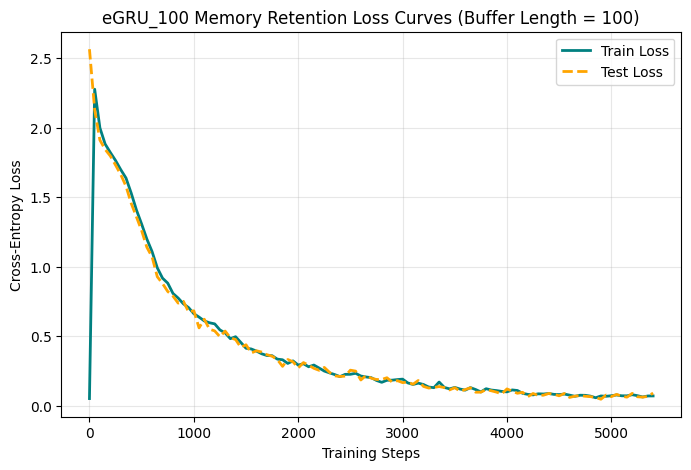

STEP: 5400 | TRAIN LOSS: 0.0718 | TEST LOSS: 0.0924


  0%|          | 0/10 [00:00<?, ?it/s]

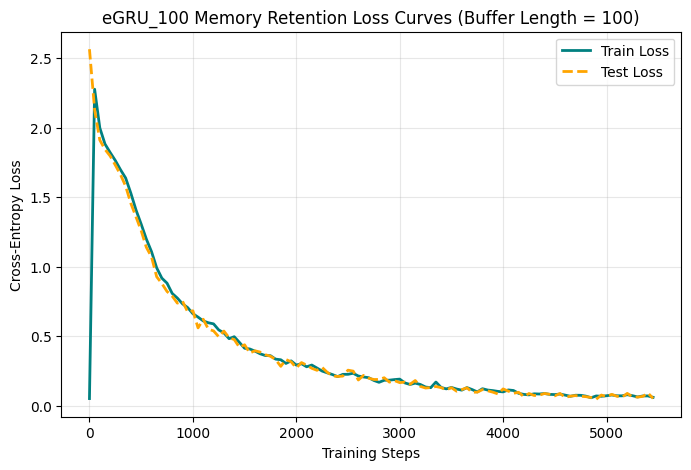

STEP: 5450 | TRAIN LOSS: 0.0618 | TEST LOSS: 0.0541


  0%|          | 0/10 [00:00<?, ?it/s]

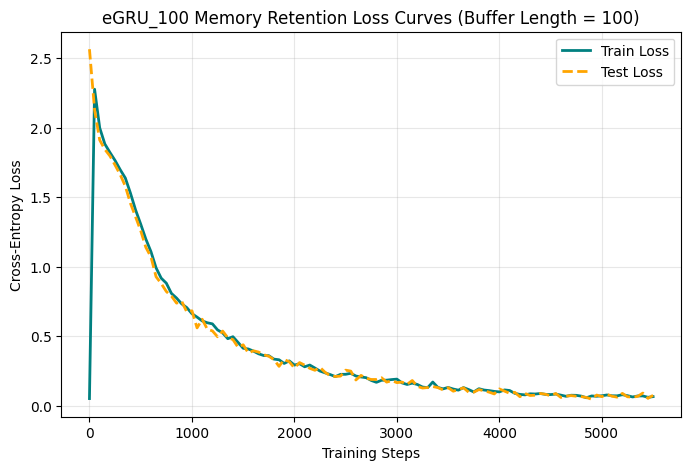

STEP: 5500 | TRAIN LOSS: 0.0668 | TEST LOSS: 0.0762


  0%|          | 0/10 [00:00<?, ?it/s]

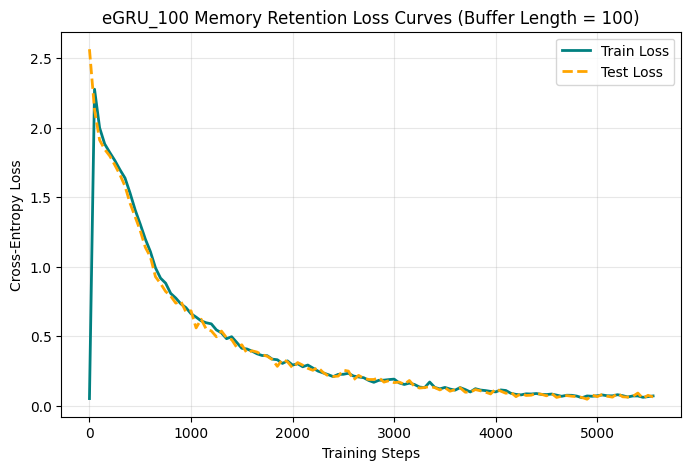

STEP: 5550 | TRAIN LOSS: 0.0716 | TEST LOSS: 0.0643


  0%|          | 0/10 [00:00<?, ?it/s]

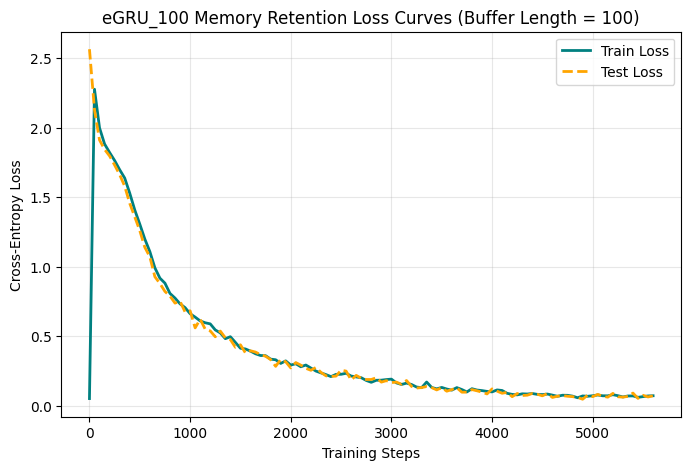

STEP: 5600 | TRAIN LOSS: 0.0731 | TEST LOSS: 0.0729


  0%|          | 0/10 [00:00<?, ?it/s]

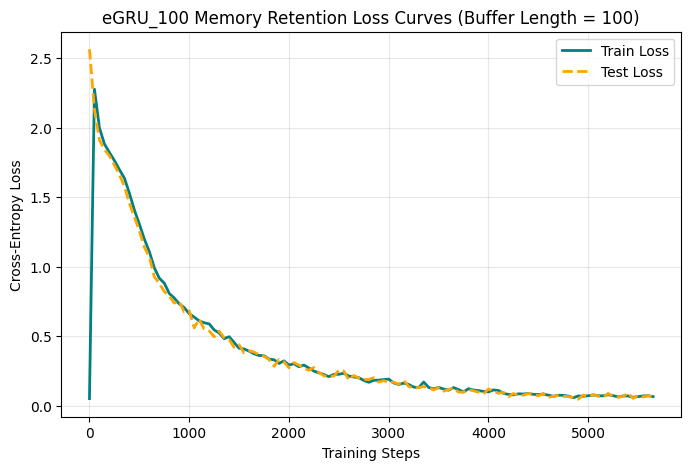

STEP: 5650 | TRAIN LOSS: 0.0670 | TEST LOSS: 0.0650


  0%|          | 0/10 [00:00<?, ?it/s]

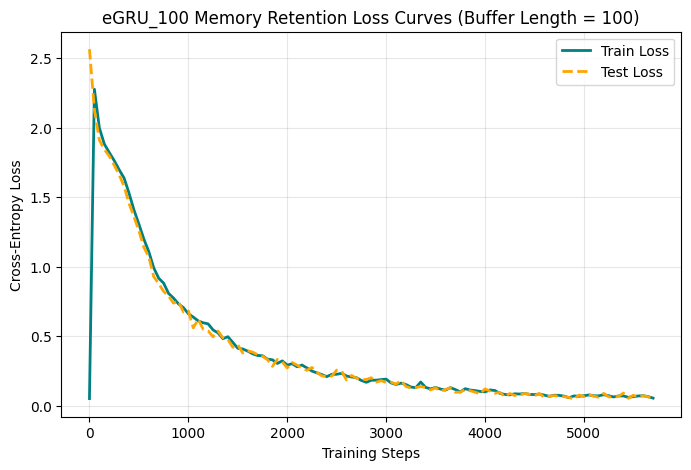

STEP: 5700 | TRAIN LOSS: 0.0560 | TEST LOSS: 0.0504


  0%|          | 0/10 [00:00<?, ?it/s]

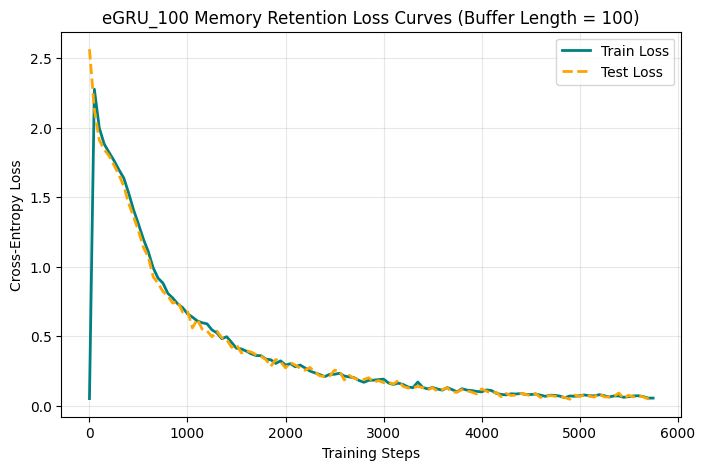

STEP: 5750 | TRAIN LOSS: 0.0563 | TEST LOSS: 0.0623


  0%|          | 0/10 [00:00<?, ?it/s]

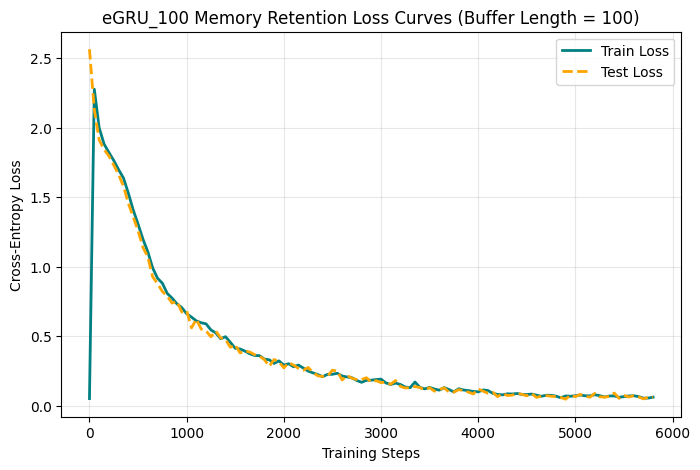

STEP: 5800 | TRAIN LOSS: 0.0628 | TEST LOSS: 0.0629


  0%|          | 0/10 [00:00<?, ?it/s]

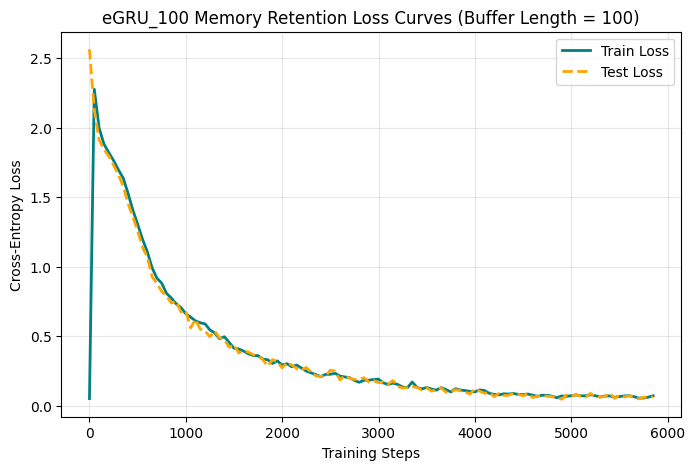

STEP: 5850 | TRAIN LOSS: 0.0727 | TEST LOSS: 0.0649


  0%|          | 0/10 [00:00<?, ?it/s]

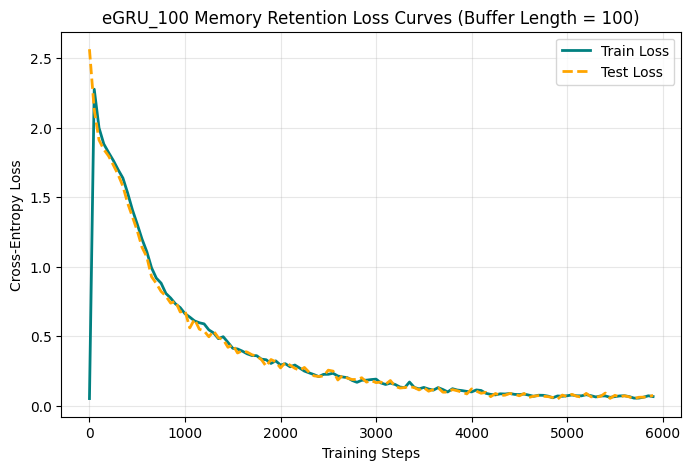

STEP: 5900 | TRAIN LOSS: 0.0672 | TEST LOSS: 0.0763


  0%|          | 0/10 [00:00<?, ?it/s]

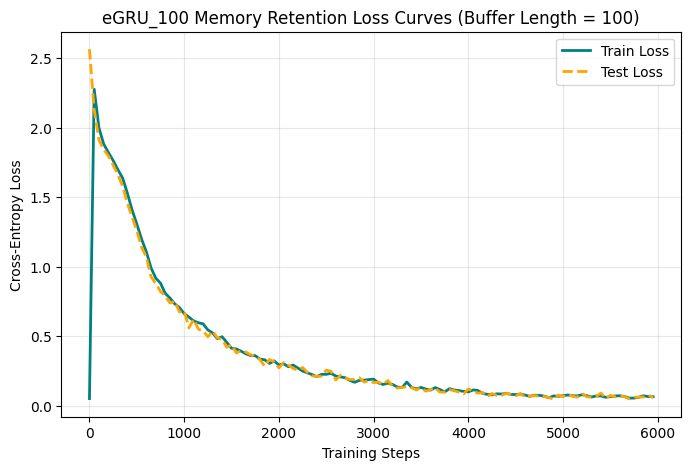

STEP: 5950 | TRAIN LOSS: 0.0659 | TEST LOSS: 0.0603


  0%|          | 0/10 [00:00<?, ?it/s]

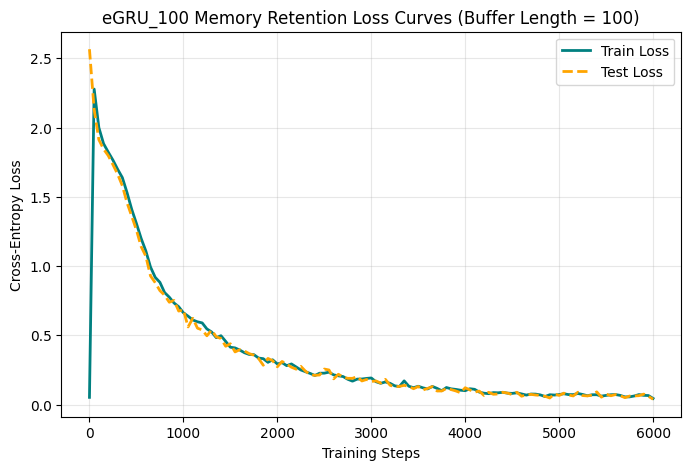

STEP: 6000 | TRAIN LOSS: 0.0449 | TEST LOSS: 0.0392


  0%|          | 0/10 [00:00<?, ?it/s]

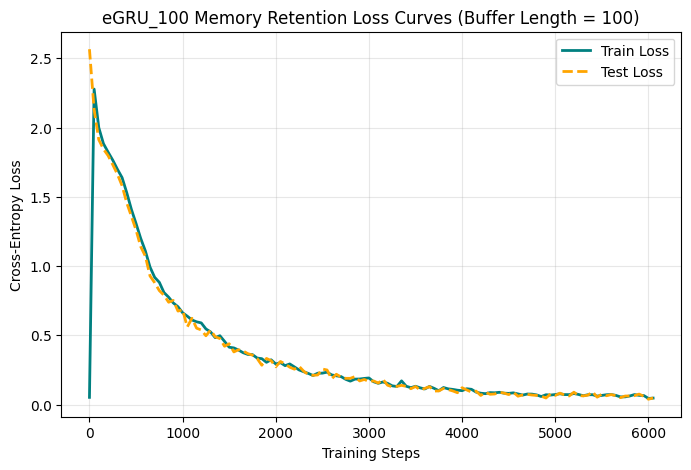

STEP: 6050 | TRAIN LOSS: 0.0474 | TEST LOSS: 0.0486


  0%|          | 0/10 [00:00<?, ?it/s]

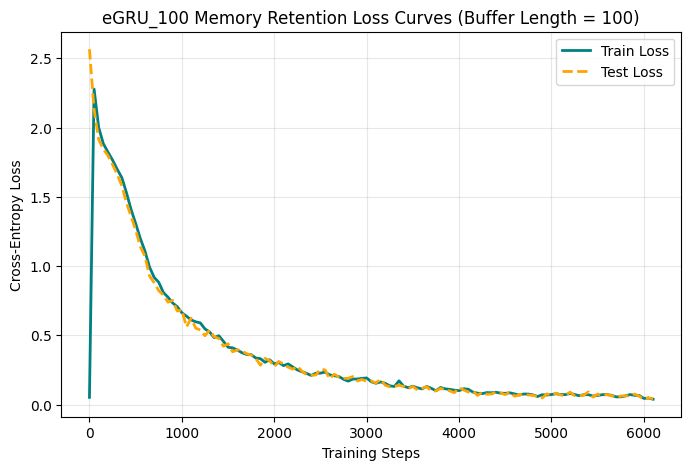

STEP: 6100 | TRAIN LOSS: 0.0391 | TEST LOSS: 0.0427


  0%|          | 0/10 [00:00<?, ?it/s]

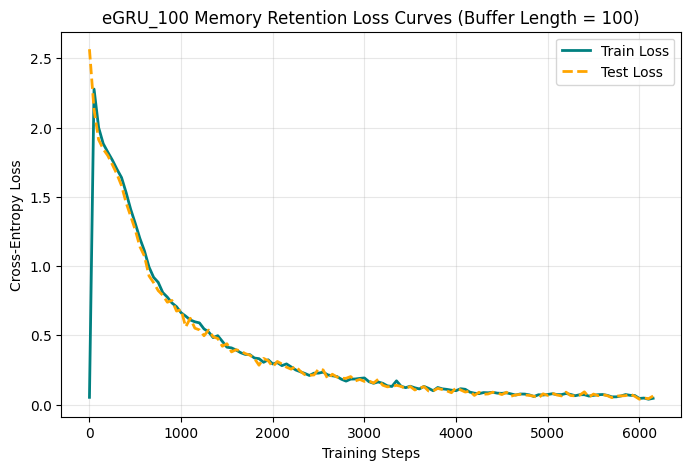

STEP: 6150 | TRAIN LOSS: 0.0458 | TEST LOSS: 0.0623


  0%|          | 0/10 [00:00<?, ?it/s]

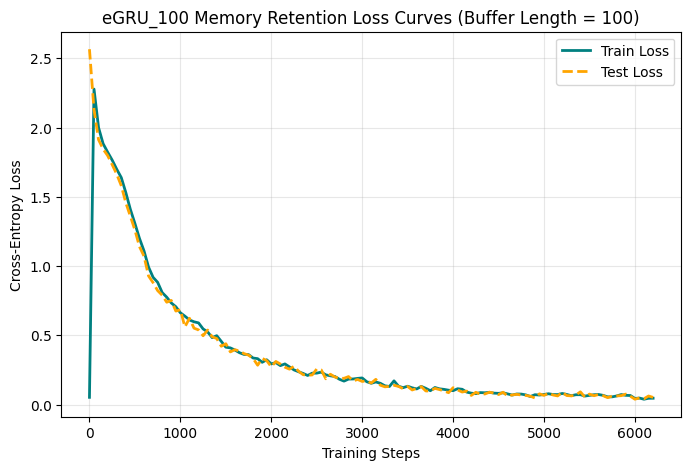

STEP: 6200 | TRAIN LOSS: 0.0463 | TEST LOSS: 0.0523


  0%|          | 0/10 [00:00<?, ?it/s]

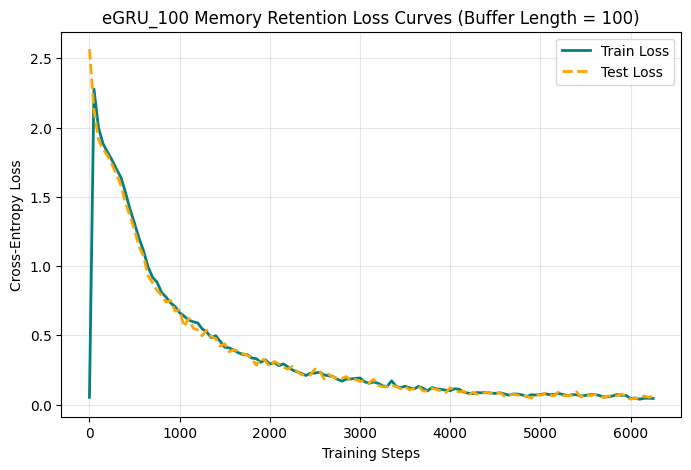

STEP: 6250 | TRAIN LOSS: 0.0448 | TEST LOSS: 0.0602


  0%|          | 0/10 [00:00<?, ?it/s]

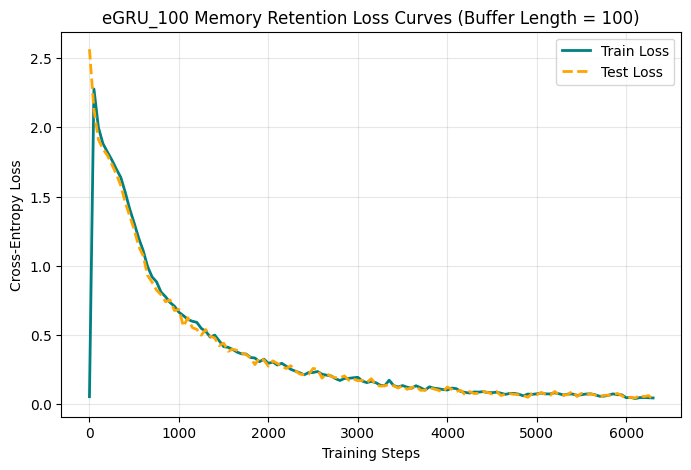

STEP: 6300 | TRAIN LOSS: 0.0433 | TEST LOSS: 0.0342


  0%|          | 0/10 [00:00<?, ?it/s]

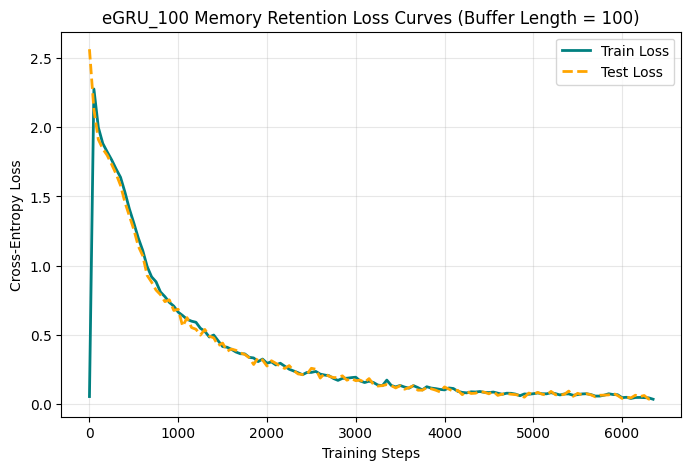

STEP: 6350 | TRAIN LOSS: 0.0334 | TEST LOSS: 0.0346


  0%|          | 0/10 [00:00<?, ?it/s]

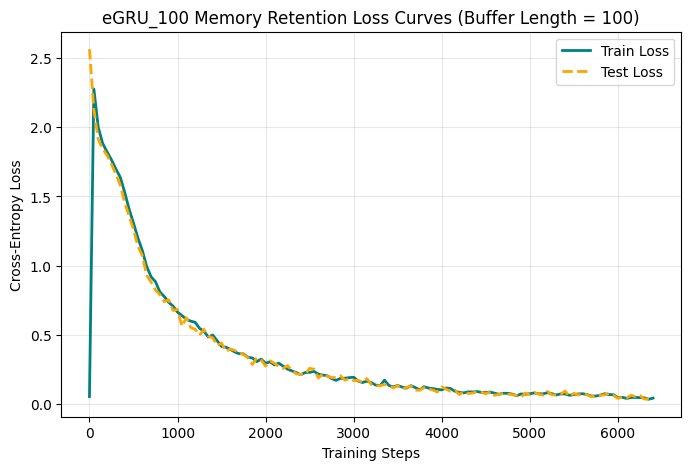

STEP: 6400 | TRAIN LOSS: 0.0414 | TEST LOSS: 0.0343


  0%|          | 0/10 [00:00<?, ?it/s]

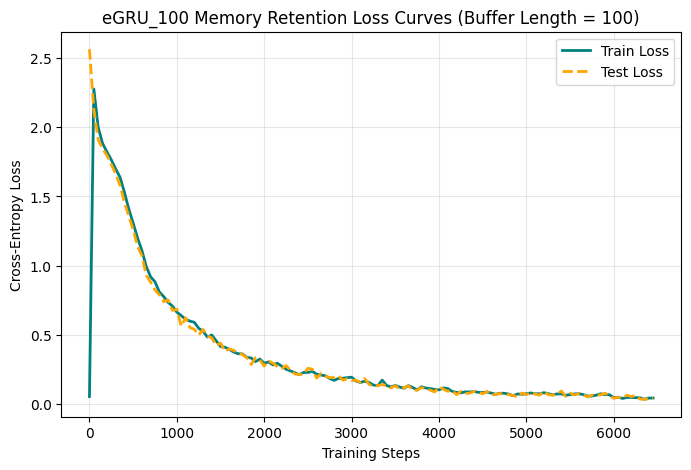

STEP: 6450 | TRAIN LOSS: 0.0423 | TEST LOSS: 0.0427


  0%|          | 0/10 [00:00<?, ?it/s]

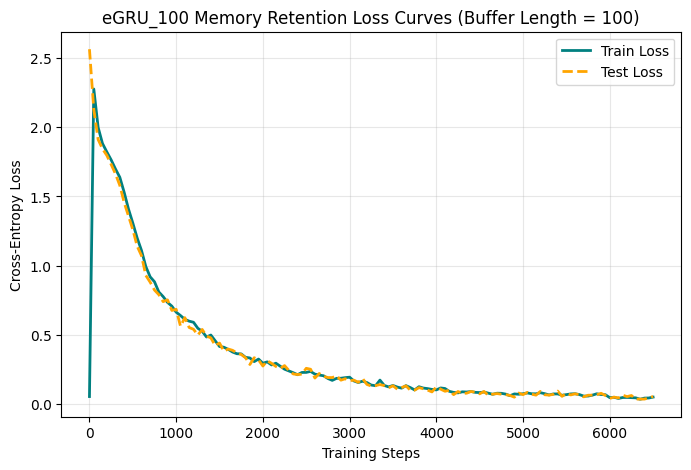

STEP: 6500 | TRAIN LOSS: 0.0486 | TEST LOSS: 0.0535


  0%|          | 0/10 [00:00<?, ?it/s]

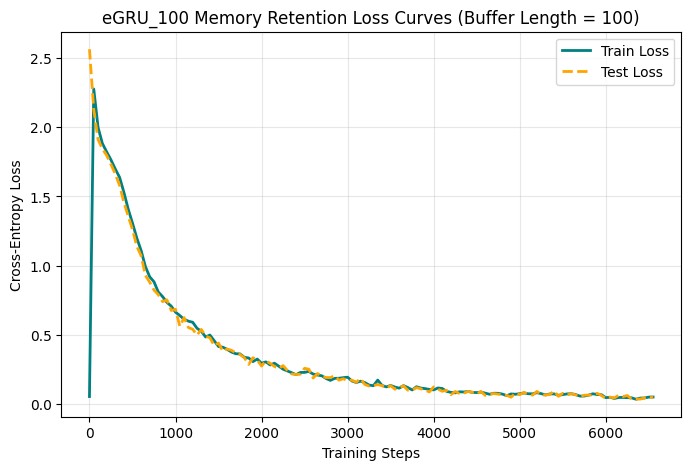

STEP: 6550 | TRAIN LOSS: 0.0493 | TEST LOSS: 0.0438


  0%|          | 0/10 [00:00<?, ?it/s]

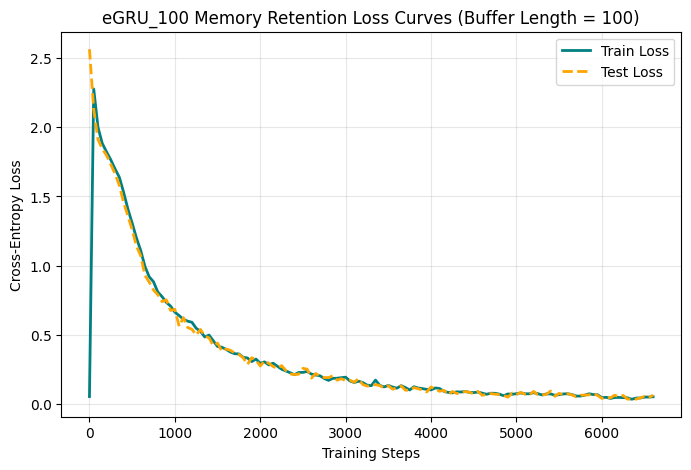

STEP: 6600 | TRAIN LOSS: 0.0510 | TEST LOSS: 0.0636


  0%|          | 0/10 [00:00<?, ?it/s]

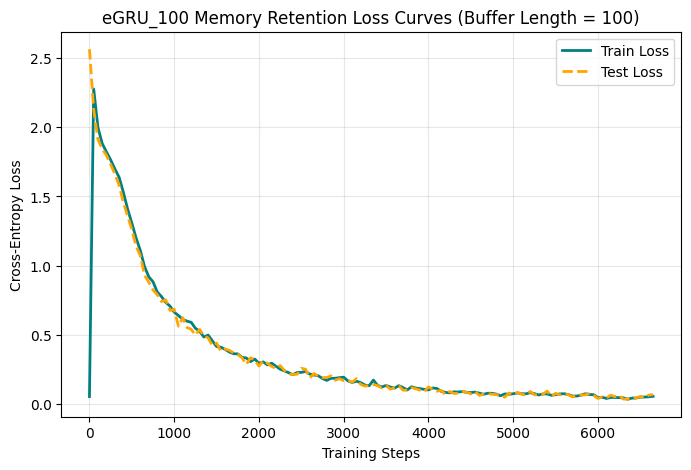

STEP: 6650 | TRAIN LOSS: 0.0543 | TEST LOSS: 0.0663


  0%|          | 0/10 [00:00<?, ?it/s]

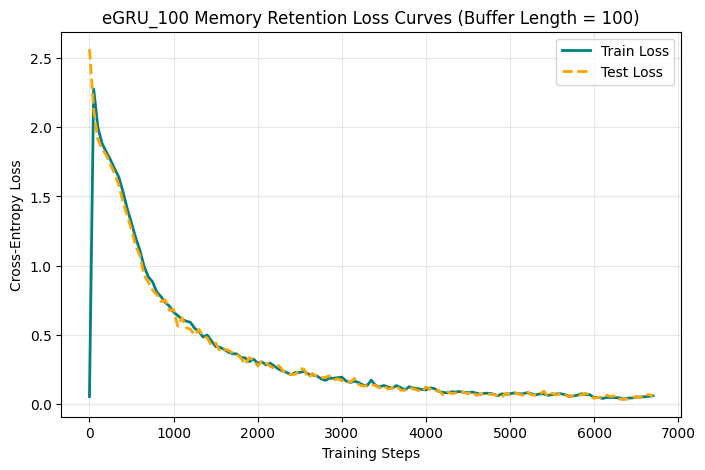

STEP: 6700 | TRAIN LOSS: 0.0583 | TEST LOSS: 0.0553


  0%|          | 0/10 [00:00<?, ?it/s]

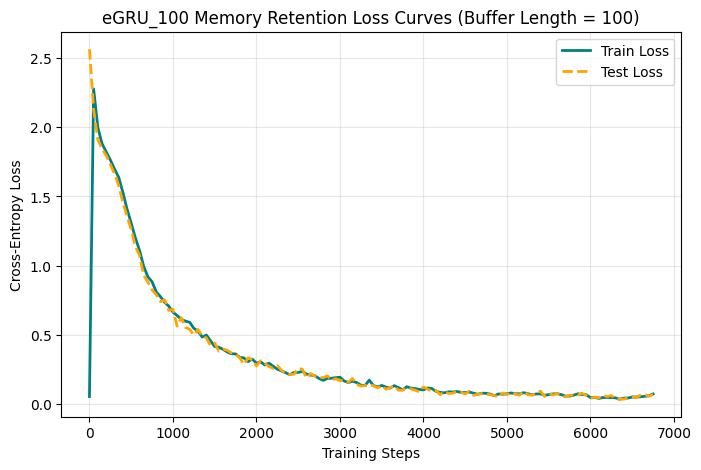

STEP: 6750 | TRAIN LOSS: 0.0715 | TEST LOSS: 0.0677


  0%|          | 0/10 [00:00<?, ?it/s]

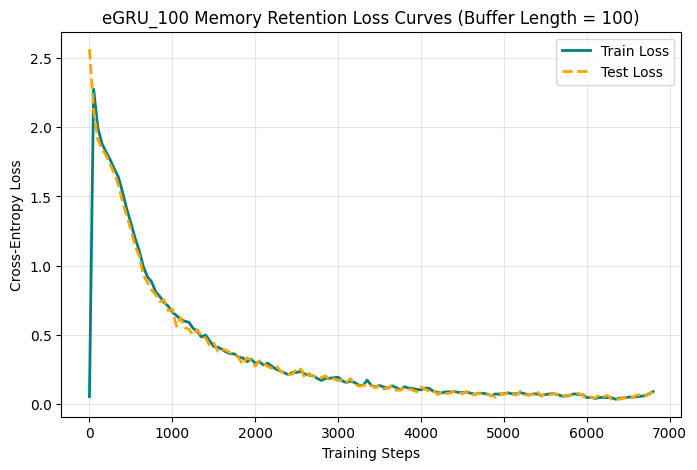

STEP: 6800 | TRAIN LOSS: 0.0887 | TEST LOSS: 0.0839


  0%|          | 0/10 [00:00<?, ?it/s]

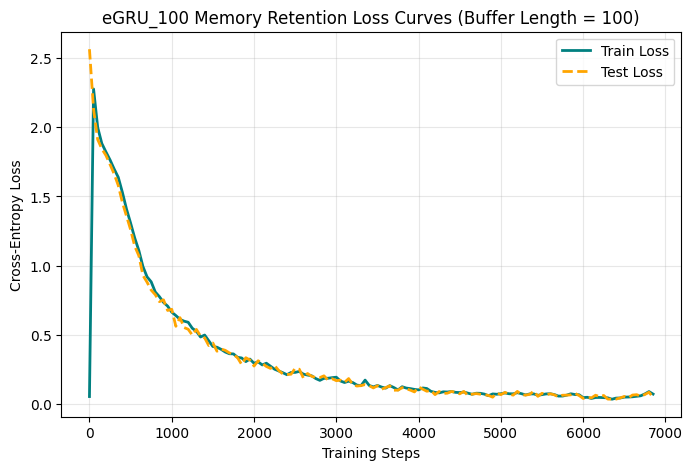

STEP: 6850 | TRAIN LOSS: 0.0706 | TEST LOSS: 0.0469


  0%|          | 0/10 [00:00<?, ?it/s]

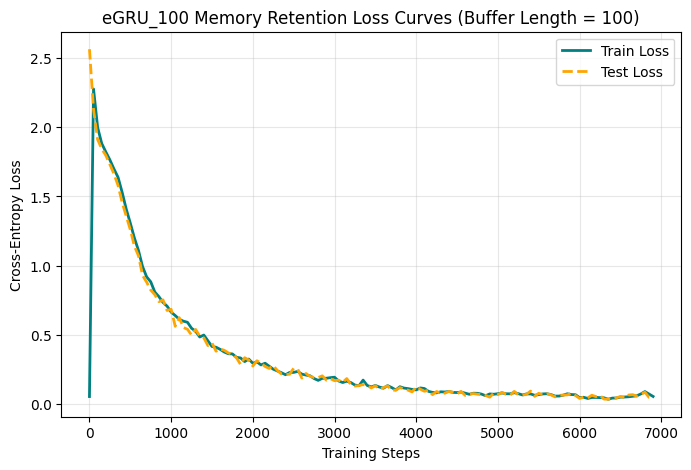

STEP: 6900 | TRAIN LOSS: 0.0534 | TEST LOSS: 0.0452


  0%|          | 0/10 [00:00<?, ?it/s]

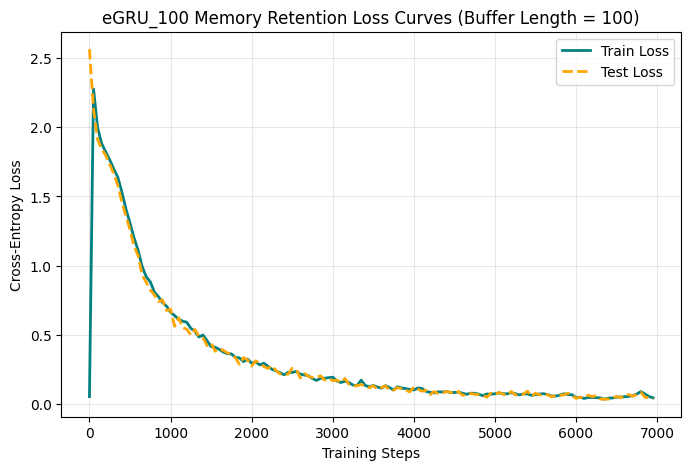

STEP: 6950 | TRAIN LOSS: 0.0435 | TEST LOSS: 0.0359


  0%|          | 0/10 [00:00<?, ?it/s]

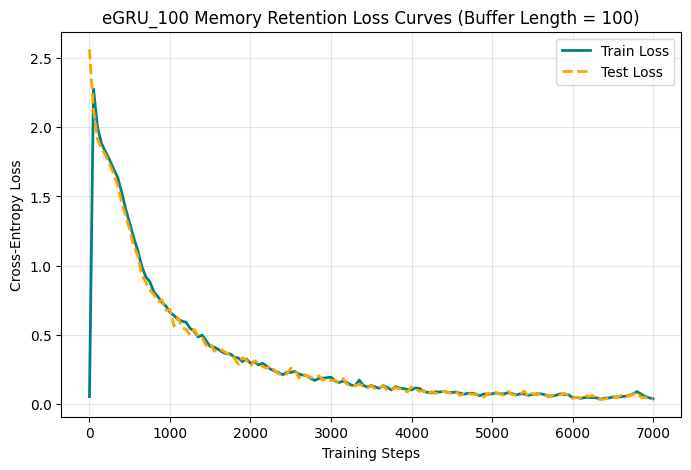

STEP: 7000 | TRAIN LOSS: 0.0366 | TEST LOSS: 0.0346


In [ ]:
from custom_models import eGRU

hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []


eGRU_model = eGRU(hid, emb, device="cuda")
opt_e = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

run_training_ex1(eGRU_model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt_e, test_break=50, model_name="eGRU_100")

In [11]:
hid_e=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

eGRU_model = eGRU(hid_e, emb, "cuda")
opt_e = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

load_model("eGRU_100_ex1_epoch_7000.pt", "cuda", eGRU_model, opt_e)

ex1_egru_50 =   evaluate_ex1(eGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_egru_100 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_egru_250 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_egru_500 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_egru_750 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_egru_1000 = evaluate_ex1(eGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("eGRU synthetic copy difference at buffer_size=50: ",   ex1_egru_50)
print("eGRU synthetic copy difference at buffer_size=100: ",  ex1_egru_100)
print("eGRU synthetic copy difference at buffer_size=250: ",  ex1_egru_250)
print("eGRU synthetic copy difference at buffer_size=500: ",  ex1_egru_500)
print("eGRU synthetic copy difference at buffer_size=750: ",  ex1_egru_750)
print("eGRU synthetic copy difference at buffer_size=1000: ", ex1_egru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU synthetic copy difference at buffer_size=50:  0.009529703169932017
eGRU synthetic copy difference at buffer_size=100:  0.009746287303912167
eGRU synthetic copy difference at buffer_size=250:  0.009158416054128567
eGRU synthetic copy difference at buffer_size=500:  0.009560643727568412
eGRU synthetic copy difference at buffer_size=750:  0.009096534846645623
eGRU synthetic copy difference at buffer_size=1000:  0.009962871483997396


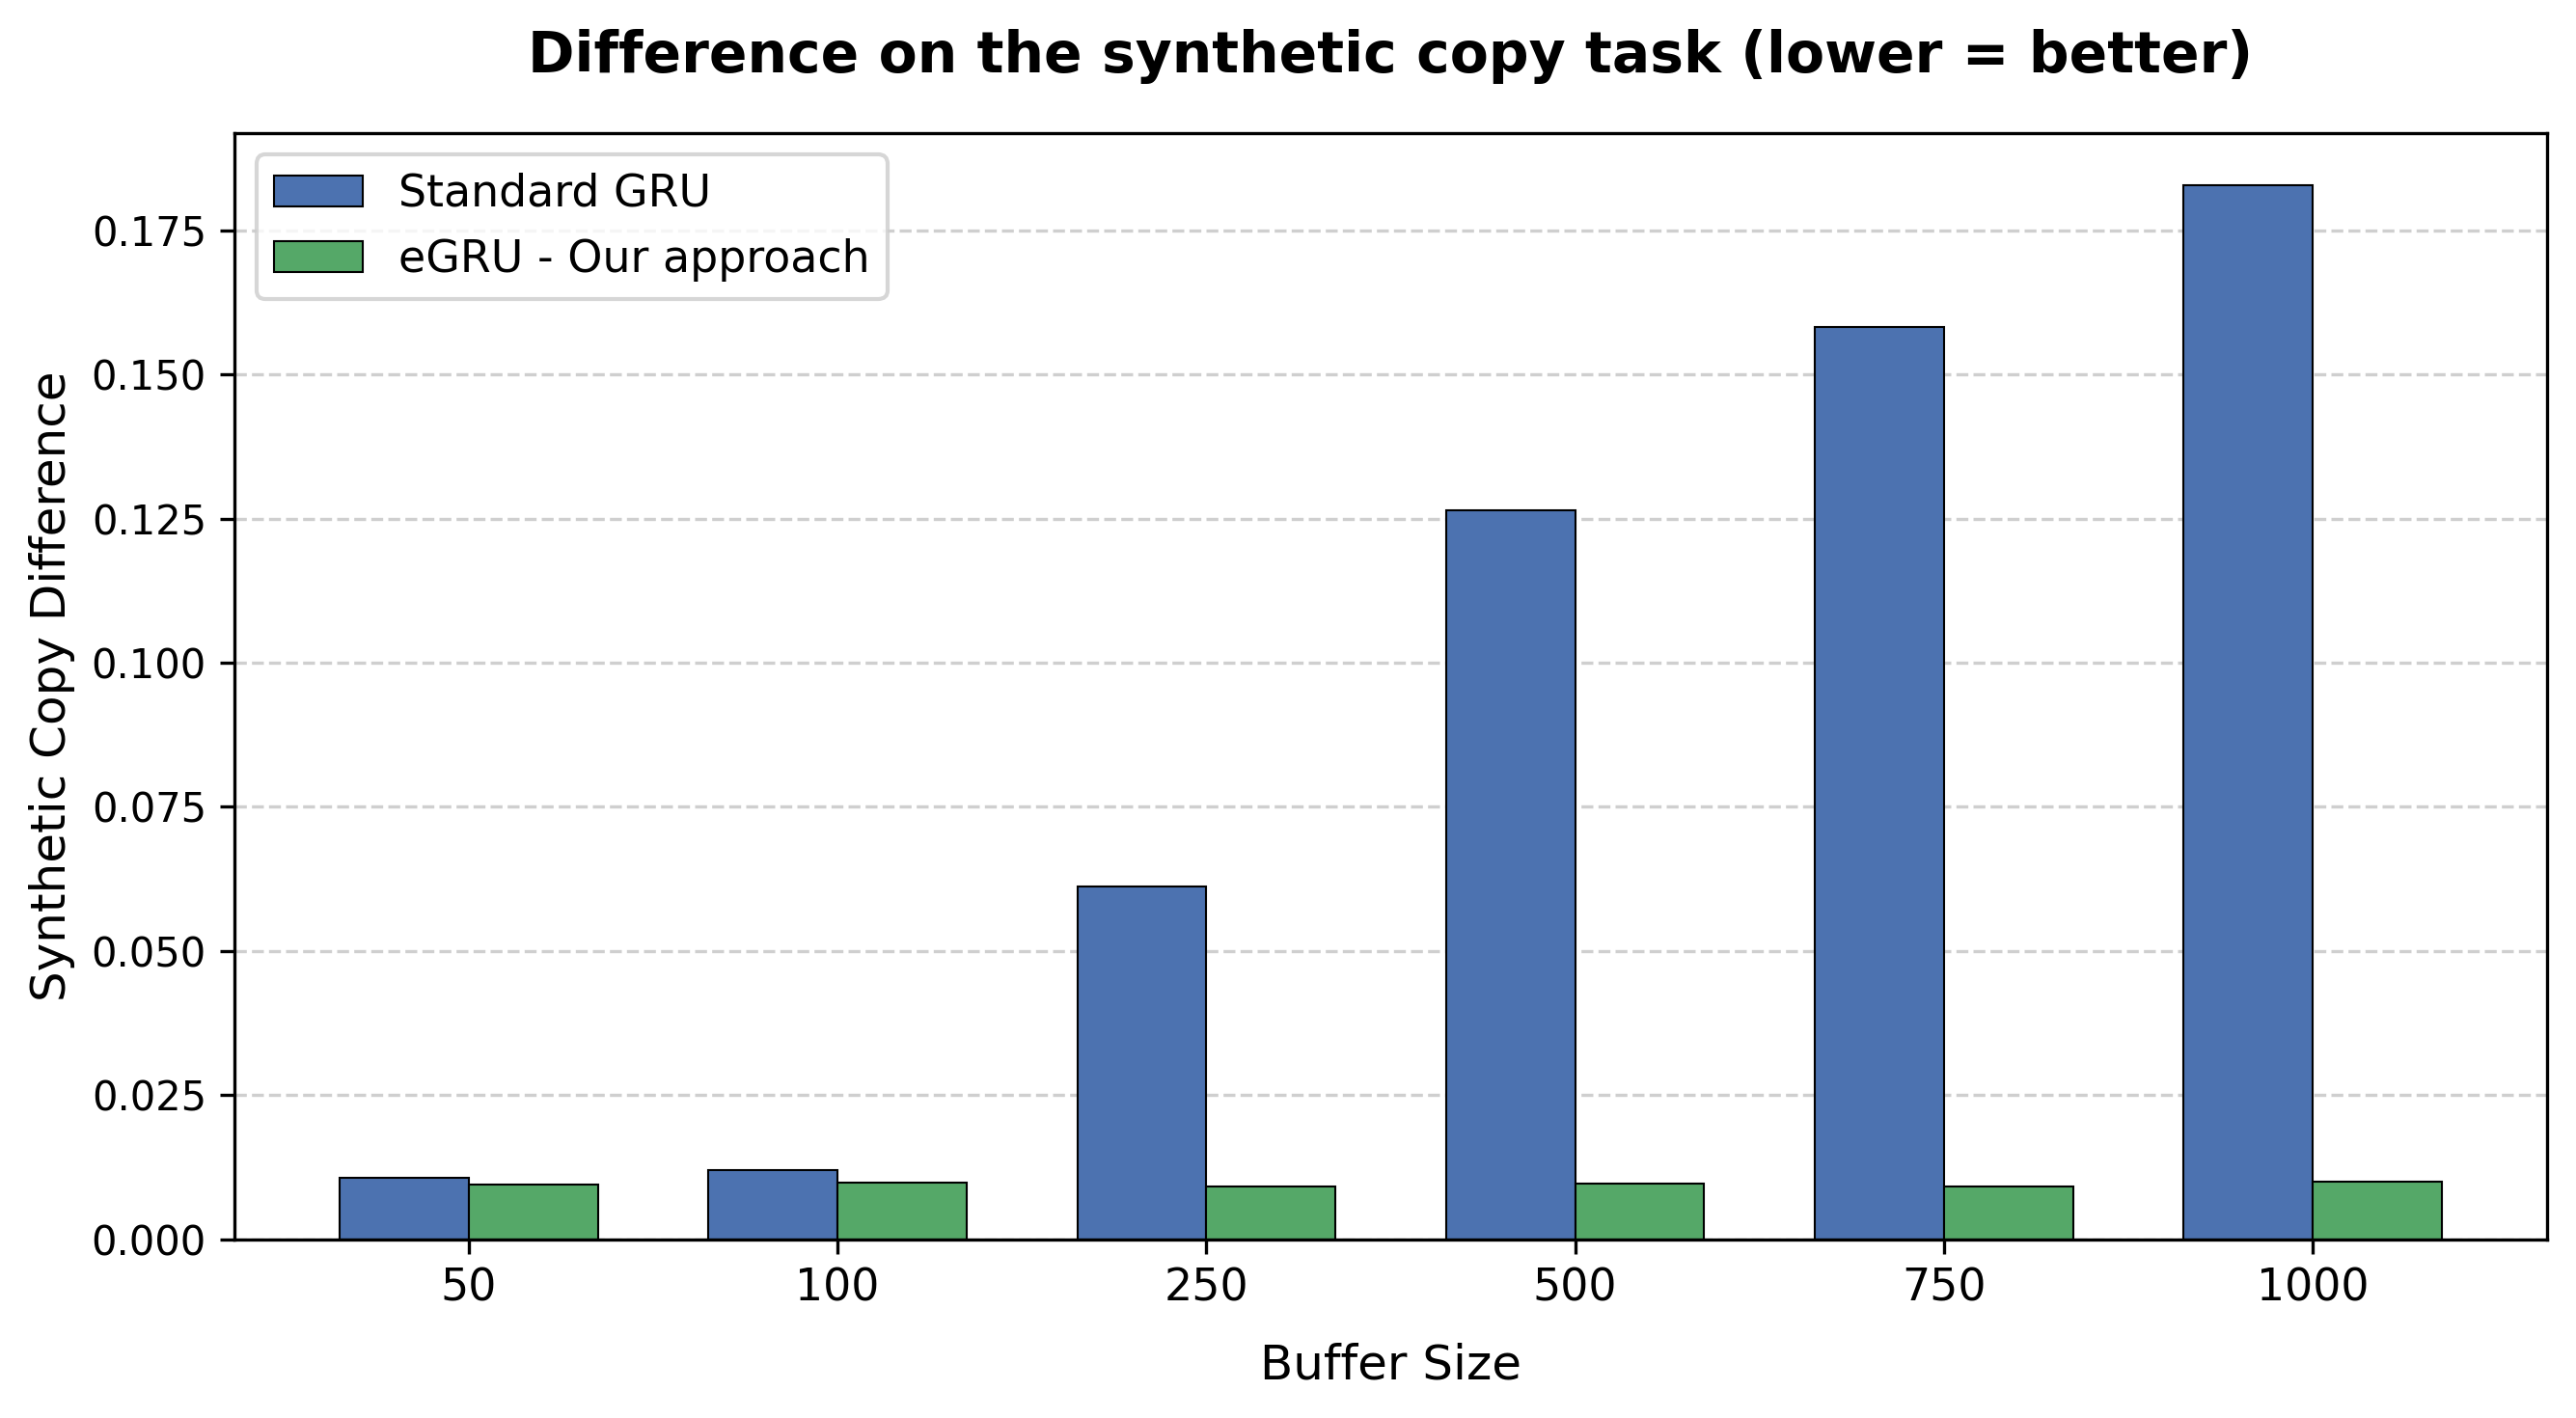

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
buffer_sizes = ["50", "100", "250", "500", "750", "1000"]
standard_gru = [
    0.010612623943569193,
    0.011974010097858782,
    0.06116955557672104,
    0.12645421036989382,
    0.15819926021417768,
    0.1828589138418141,
]
egru = [
    0.009529703169932017,
    0.009746287303912167,
    0.009158416054128567,
    0.009560643727568412,
    0.009096534846645623,
    0.009962871483997396,
]

# Plot setup
x = np.arange(len(buffer_sizes))  # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Create bars
rects1 = ax.bar(
    x - width / 2,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)
rects2 = ax.bar(
    x + width / 2,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

# Titles and labels
ax.set_title(
    "Difference on the synthetic copy task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Buffer Size", fontsize=12, fontweight="medium", labelpad=8)
ax.set_ylabel("Synthetic Copy Difference", fontsize=12, fontweight="medium")
ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)

# Aesthetics
ax.legend(fontsize=11, frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_axisbelow(True)  # Grid behind the bars

# Adjust layout and display
plt.tight_layout()
plt.show()